In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real'
path_sim = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

In [ ]:
kaggle api export KAGGLE_API_TOKEN=KGAT_bcaf5f392d9f61ac0c831a01b96cc2c8

In [2]:
pip install h5py

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import re
import json
import math
import zipfile
import traceback
from collections import defaultdict

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

OUTPUT_DIR = '/kaggle/working/realpde_full_audit'
ZIP_PATH   = '/kaggle/working/realpde_full_audit.zip'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Limit number of time slices used for expensive global statistics.
# This does NOT limit metadata/shape scanning.
MAX_TIME_SAMPLES_PER_FILE = 64

# Representative number of files for plotting.
MAX_PLOT_FILES_PER_DOMAIN = 12

# Number of spatial snapshots saved from each representative file.
SNAPSHOTS_PER_FILE = 3

# Percentiles to estimate.
PERCENTILES = [0.1, 1, 5, 25, 50, 75, 95, 99, 99.9]


# ============================================================
# HELPERS
# ============================================================

def json_safe(x):
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, bytes):
        try:
            return x.decode()
        except Exception:
            return str(x)
    return x


def sanitize_name(s):
    s = str(s)
    s = re.sub(r'[^a-zA-Z0-9_.-]+', '_', s)
    return s[:160]


def list_h5_files(path):
    out = []
    for root, _, files in os.walk(path):
        for f in files:
            if f.lower().endswith(('.h5', '.hdf5')):
                out.append(os.path.join(root, f))
    return sorted(out)


def infer_from_filename(filename):
    """
    Try to parse patterns like:
        3750_0.h5
        Re3750_AoA0.h5
    """
    base = os.path.splitext(os.path.basename(filename))[0]

    result = {
        "filename_Re_guess": np.nan,
        "filename_AoA_guess": np.nan
    }

    nums = re.findall(r'-?\d+(?:\.\d+)?', base)

    if len(nums) >= 2:
        try:
            result["filename_Re_guess"] = float(nums[0])
            result["filename_AoA_guess"] = float(nums[1])
        except Exception:
            pass

    return result


def dataset_structure(f):
    rows = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "dataset": name,
                "shape": str(obj.shape),
                "ndim": obj.ndim,
                "dtype": str(obj.dtype),
                "size": int(obj.size),
                "compression": str(obj.compression),
            })

    f.visititems(visitor)
    return rows


def find_candidate_dataset(f, candidates):
    """
    Search exact basename first, then fuzzy match.
    candidates example: ['u', 'velocity_u']
    """
    found = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            base = name.split("/")[-1].lower()
            found.append((name, base))

    f.visititems(visitor)

    # exact
    for c in candidates:
        c = c.lower()
        for full, base in found:
            if base == c:
                return full

    # fuzzy
    for c in candidates:
        c = c.lower()
        for full, base in found:
            if c in base:
                return full

    return None


def find_metadata_value(f, possible_names):
    possible_names = [x.lower() for x in possible_names]

    # root attrs
    for k, v in f.attrs.items():
        if k.lower() in possible_names:
            try:
                arr = np.asarray(v)
                if arr.size == 1:
                    return json_safe(arr.reshape(-1)[0])
                return json_safe(arr)
            except Exception:
                return json_safe(v)

    # group/dataset attrs
    result = None

    def visitor(name, obj):
        nonlocal result

        if result is not None:
            return

        for k, v in obj.attrs.items():
            if k.lower() in possible_names:
                try:
                    arr = np.asarray(v)
                    if arr.size == 1:
                        result = json_safe(arr.reshape(-1)[0])
                    else:
                        result = json_safe(arr)
                except Exception:
                    result = json_safe(v)
                return

        if isinstance(obj, h5py.Dataset):
            base = name.split("/")[-1].lower()

            if base in possible_names and obj.size <= 100:
                try:
                    arr = obj[()]
                    arr = np.asarray(arr)
                    if arr.size == 1:
                        result = json_safe(arr.reshape(-1)[0])
                    else:
                        result = json_safe(arr)
                except Exception:
                    pass

    f.visititems(visitor)

    return result


def choose_time_indices(n, max_samples=64):
    if n <= max_samples:
        return np.arange(n, dtype=int)

    return np.unique(
        np.linspace(0, n - 1, max_samples).astype(int)
    )


def safe_read_samples(ds, indices=None):
    """
    Reads selected samples along axis 0.
    For static arrays, reads whole dataset.
    """
    if ds.ndim == 0:
        return np.asarray(ds[()])

    if indices is None:
        return np.asarray(ds[()])

    # h5py advanced indexing requires sorted indices
    indices = np.asarray(sorted(set(map(int, indices))))
    return np.asarray(ds[indices])


def finite_stats(x):
    x = np.asarray(x)

    total = x.size

    if total == 0:
        return {}

    finite = np.isfinite(x)
    xf = x[finite]

    out = {
        "count": int(total),
        "finite_count": int(finite.sum()),
        "nan_count": int(np.isnan(x).sum()) if np.issubdtype(x.dtype, np.number) else 0,
        "inf_count": int(np.isinf(x).sum()) if np.issubdtype(x.dtype, np.number) else 0,
        "zero_count": int(np.sum(x == 0)),
        "zero_fraction": float(np.mean(x == 0)),
    }

    if xf.size == 0:
        out.update({
            "min": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "std": np.nan,
            "abs_mean": np.nan,
        })
        return out

    out.update({
        "min": float(np.min(xf)),
        "max": float(np.max(xf)),
        "mean": float(np.mean(xf)),
        "std": float(np.std(xf)),
        "abs_mean": float(np.mean(np.abs(xf))),
    })

    for p in PERCENTILES:
        out[f"p{str(p).replace('.', '_')}"] = float(np.percentile(xf, p))

    return out


def detect_time_axis_shape(arr):
    """
    Assumption: trajectory arrays usually [T,H,W].
    """
    if arr.ndim >= 3:
        return arr.shape[0]
    return None


def temporal_autocorr_lag1(x):
    """
    Global lag-1 correlation using flattened spatial fields.
    x expected [T,...].
    """
    x = np.asarray(x)

    if x.ndim < 2 or x.shape[0] < 2:
        return np.nan

    a = x[:-1].reshape(x.shape[0] - 1, -1)
    b = x[1:].reshape(x.shape[0] - 1, -1)

    a = a.ravel()
    b = b.ravel()

    mask = np.isfinite(a) & np.isfinite(b)

    if mask.sum() < 10:
        return np.nan

    a = a[mask]
    b = b[mask]

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def mean_abs_temporal_delta(x):
    x = np.asarray(x)

    if x.ndim < 2 or x.shape[0] < 2:
        return np.nan

    d = np.diff(x, axis=0)
    finite = np.isfinite(d)

    if not finite.any():
        return np.nan

    return float(np.mean(np.abs(d[finite])))


def compute_tke_proxy(u, v):
    """
    TKE proxy from resolved 2D velocity fluctuations:

        0.5 * (u'^2 + v'^2)

    averaged over sampled time.
    """
    if u is None or v is None:
        return None

    if u.shape != v.shape:
        return None

    if u.ndim < 3:
        return None

    u_mean = np.nanmean(u, axis=0)
    v_mean = np.nanmean(v, axis=0)

    up = u - u_mean
    vp = v - v_mean

    return 0.5 * np.nanmean(up**2 + vp**2, axis=0)


def spatial_gradient_proxy(x):
    """
    Mean |grad x| over time/space.
    """
    if x is None or x.ndim < 3:
        return np.nan

    try:
        gy = np.gradient(x, axis=-2)
        gx = np.gradient(x, axis=-1)

        g = np.sqrt(gx**2 + gy**2)
        return float(np.nanmean(g))
    except Exception:
        return np.nan


def compute_vorticity_proxy(u, v):
    """
    omega_z = dv/dx - du/dy
    grid spacing assumed normalized.
    """
    if u is None or v is None:
        return None

    if u.shape != v.shape or u.ndim < 3:
        return None

    try:
        dv_dx = np.gradient(v, axis=-1)
        du_dy = np.gradient(u, axis=-2)
        return dv_dx - du_dy
    except Exception:
        return None


def save_field_image(field, title, path):
    field = np.asarray(field)

    plt.figure(figsize=(8, 4))
    plt.imshow(field, origin='lower', aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=130)
    plt.close()


# ============================================================
# AUDIT STORAGE
# ============================================================

file_rows = []
dataset_rows = []
channel_rows = []
errors = []

representative_data = {
    "real": [],
    "sim": []
}


# ============================================================
# MAIN FILE AUDIT
# ============================================================

def audit_domain(domain_name, root_path):
    files = list_h5_files(root_path)

    print("=" * 100)
    print(domain_name.upper())
    print("files:", len(files))
    print("=" * 100)

    for file_idx, file_path in enumerate(files):

        rel_path = os.path.relpath(file_path, root_path)
        filename = os.path.basename(file_path)

        print(
            f"[{domain_name}] "
            f"{file_idx + 1:4d}/{len(files):4d} "
            f"{rel_path}"
        )

        try:
            with h5py.File(file_path, 'r') as f:

                guesses = infer_from_filename(filename)

                Re = find_metadata_value(
                    f,
                    ['re', 'reynolds', 'reynolds_number']
                )

                AoA = find_metadata_value(
                    f,
                    ['aoa', 'angle_of_attack', 'alpha']
                )

                time_name = find_candidate_dataset(
                    f,
                    ['t', 'time', 'times']
                )

                u_name = find_candidate_dataset(
                    f,
                    ['u', 'velocity_u', 'ux']
                )

                v_name = find_candidate_dataset(
                    f,
                    ['v', 'velocity_v', 'uy']
                )

                p_name = find_candidate_dataset(
                    f,
                    ['p', 'pressure']
                )

                temp_name = find_candidate_dataset(
                    f,
                    ['temperature', 'temp']
                )

                # ----------------------------
                # structure table
                # ----------------------------

                struct = dataset_structure(f)

                for r in struct:
                    r.update({
                        "domain": domain_name,
                        "file": rel_path,
                    })
                    dataset_rows.append(r)

                # ----------------------------
                # identify trajectory length
                # ----------------------------

                candidate_T = []

                for nm in [u_name, v_name, p_name, temp_name]:
                    if nm is not None:
                        ds = f[nm]
                        if ds.ndim >= 3:
                            candidate_T.append(ds.shape[0])

                T = candidate_T[0] if candidate_T else np.nan

                # ----------------------------
                # time stats
                # ----------------------------

                dt_mean = np.nan
                dt_std = np.nan
                t_start = np.nan
                t_end = np.nan

                if time_name is not None:
                    try:
                        tt = np.asarray(f[time_name][()]).squeeze()

                        if tt.ndim == 1 and len(tt) > 0:
                            t_start = float(tt[0])
                            t_end = float(tt[-1])

                            if len(tt) > 1:
                                dt = np.diff(tt)
                                dt_mean = float(np.mean(dt))
                                dt_std = float(np.std(dt))

                    except Exception:
                        pass

                # ----------------------------
                # file-level info
                # ----------------------------

                file_rows.append({
                    "domain": domain_name,
                    "file": rel_path,
                    "filename": filename,
                    "file_size_MB": os.path.getsize(file_path) / 1024**2,

                    "Re": Re,
                    "AoA": AoA,

                    **guesses,

                    "T": T,

                    "u_dataset": u_name,
                    "v_dataset": v_name,
                    "p_dataset": p_name,
                    "temperature_dataset": temp_name,
                    "time_dataset": time_name,

                    "t_start": t_start,
                    "t_end": t_end,
                    "dt_mean": dt_mean,
                    "dt_std": dt_std,

                    "num_datasets": len(struct),

                    "root_keys": "|".join(map(str, f.keys())),
                    "root_attrs": json.dumps(
                        {k: json_safe(v) for k, v in f.attrs.items()},
                        default=str
                    )
                })

                # ----------------------------
                # sample temporal fields
                # ----------------------------

                arrays = {}

                for channel, ds_name in [
                    ("u", u_name),
                    ("v", v_name),
                    ("p", p_name),
                    ("temperature", temp_name)
                ]:

                    if ds_name is None:
                        continue

                    ds = f[ds_name]

                    try:

                        if ds.ndim >= 3:
                            idx = choose_time_indices(
                                ds.shape[0],
                                MAX_TIME_SAMPLES_PER_FILE
                            )

                            arr = safe_read_samples(ds, idx)

                        else:
                            arr = np.asarray(ds[()])

                        arrays[channel] = arr

                        stats = finite_stats(arr)

                        stats.update({
                            "domain": domain_name,
                            "file": rel_path,
                            "channel": channel,
                            "dataset": ds_name,
                            "shape_full": str(ds.shape),
                            "shape_sampled": str(arr.shape),
                            "dtype": str(ds.dtype),
                        })

                        if arr.ndim >= 3:
                            stats["lag1_corr_sampled"] = temporal_autocorr_lag1(arr)
                            stats["mean_abs_dt_sampled"] = mean_abs_temporal_delta(arr)
                            stats["mean_spatial_gradient"] = spatial_gradient_proxy(arr)
                        else:
                            stats["lag1_corr_sampled"] = np.nan
                            stats["mean_abs_dt_sampled"] = np.nan
                            stats["mean_spatial_gradient"] = np.nan

                        channel_rows.append(stats)

                    except Exception as e:

                        errors.append({
                            "domain": domain_name,
                            "file": rel_path,
                            "stage": f"read_channel_{channel}",
                            "error": repr(e)
                        })

                # ====================================================
                # DERIVED U,V METRICS
                # ====================================================

                u = arrays.get("u")
                v = arrays.get("v")

                if (
                    u is not None and
                    v is not None and
                    u.shape == v.shape
                ):

                    speed = np.sqrt(u**2 + v**2)

                    speed_stats = finite_stats(speed)

                    speed_stats.update({
                        "domain": domain_name,
                        "file": rel_path,
                        "channel": "speed",
                        "dataset": "derived_sqrt_u2_v2",
                        "shape_full": str(speed.shape),
                        "shape_sampled": str(speed.shape),
                        "dtype": str(speed.dtype),
                        "lag1_corr_sampled": temporal_autocorr_lag1(speed)
                            if speed.ndim >= 3 else np.nan,
                        "mean_abs_dt_sampled": mean_abs_temporal_delta(speed)
                            if speed.ndim >= 3 else np.nan,
                        "mean_spatial_gradient": spatial_gradient_proxy(speed)
                            if speed.ndim >= 3 else np.nan,
                    })

                    channel_rows.append(speed_stats)

                    vort = compute_vorticity_proxy(u, v)

                    if vort is not None:

                        vort_stats = finite_stats(vort)

                        vort_stats.update({
                            "domain": domain_name,
                            "file": rel_path,
                            "channel": "vorticity_proxy",
                            "dataset": "derived_dv_dx_minus_du_dy",
                            "shape_full": str(vort.shape),
                            "shape_sampled": str(vort.shape),
                            "dtype": str(vort.dtype),
                            "lag1_corr_sampled": temporal_autocorr_lag1(vort),
                            "mean_abs_dt_sampled": mean_abs_temporal_delta(vort),
                            "mean_spatial_gradient": spatial_gradient_proxy(vort),
                        })

                        channel_rows.append(vort_stats)

                    tke = compute_tke_proxy(u, v)

                    if tke is not None:

                        tke_stats = finite_stats(tke)

                        tke_stats.update({
                            "domain": domain_name,
                            "file": rel_path,
                            "channel": "TKE_proxy",
                            "dataset": "derived",
                            "shape_full": str(tke.shape),
                            "shape_sampled": str(tke.shape),
                            "dtype": str(tke.dtype),
                            "lag1_corr_sampled": np.nan,
                            "mean_abs_dt_sampled": np.nan,
                            "mean_spatial_gradient": spatial_gradient_proxy(
                                tke[None]
                            ),
                        })

                        channel_rows.append(tke_stats)

                # ====================================================
                # REPRESENTATIVE DATA FOR VISUALIZATION
                # ====================================================

                if len(representative_data[domain_name]) < MAX_PLOT_FILES_PER_DOMAIN:

                    item = {
                        "file": rel_path,
                        "Re": Re,
                        "AoA": AoA,
                    }

                    if u is not None and u.ndim >= 3:
                        item["u_mean"] = np.nanmean(u, axis=0)
                        item["u_std"] = np.nanstd(u, axis=0)

                    if v is not None and v.ndim >= 3:
                        item["v_mean"] = np.nanmean(v, axis=0)
                        item["v_std"] = np.nanstd(v, axis=0)

                    if (
                        u is not None and
                        v is not None and
                        u.ndim >= 3 and
                        u.shape == v.shape
                    ):

                        speed = np.sqrt(u**2 + v**2)

                        item["speed_mean"] = np.nanmean(speed, axis=0)
                        item["speed_std"] = np.nanstd(speed, axis=0)

                        tke = compute_tke_proxy(u, v)

                        if tke is not None:
                            item["tke"] = tke

                        vort = compute_vorticity_proxy(u, v)

                        if vort is not None:
                            item["vorticity_mean"] = np.nanmean(vort, axis=0)

                        # snapshots
                        ids = choose_time_indices(
                            u.shape[0],
                            SNAPSHOTS_PER_FILE
                        )

                        item["u_snapshots"] = u[ids]
                        item["v_snapshots"] = v[ids]

                    representative_data[domain_name].append(item)

        except Exception as e:

            print("  ERROR:", repr(e))

            errors.append({
                "domain": domain_name,
                "file": rel_path,
                "stage": "open_file",
                "error": repr(e),
                "traceback": traceback.format_exc()
            })


# ============================================================
# RUN
# ============================================================

audit_domain("real", path_real)
audit_domain("sim", path_sim)


# ============================================================
# DATAFRAMES
# ============================================================

files_df = pd.DataFrame(file_rows)
datasets_df = pd.DataFrame(dataset_rows)
channels_df = pd.DataFrame(channel_rows)
errors_df = pd.DataFrame(errors)

files_csv = os.path.join(OUTPUT_DIR, 'files.csv')
datasets_csv = os.path.join(OUTPUT_DIR, 'datasets.csv')
channels_csv = os.path.join(OUTPUT_DIR, 'channel_statistics.csv')
errors_csv = os.path.join(OUTPUT_DIR, 'errors.csv')

files_df.to_csv(files_csv, index=False)
datasets_df.to_csv(datasets_csv, index=False)
channels_df.to_csv(channels_csv, index=False)
errors_df.to_csv(errors_csv, index=False)


# ============================================================
# DOMAIN SUMMARY
# ============================================================

summary = {}

for domain in ["real", "sim"]:

    fdf = files_df[files_df.domain == domain]
    cdf = channels_df[channels_df.domain == domain]

    summary[domain] = {
        "num_files": int(len(fdf)),
        "total_size_GB": float(fdf["file_size_MB"].sum() / 1024)
            if len(fdf) else 0,

        "Re_values": sorted(
            pd.to_numeric(fdf["Re"], errors="coerce")
            .dropna()
            .unique()
            .tolist()
        ) if "Re" in fdf else [],

        "AoA_values": sorted(
            pd.to_numeric(fdf["AoA"], errors="coerce")
            .dropna()
            .unique()
            .tolist()
        ) if "AoA" in fdf else [],

        "trajectory_lengths": sorted(
            pd.to_numeric(fdf["T"], errors="coerce")
            .dropna()
            .unique()
            .tolist()
        ) if "T" in fdf else [],

        "channels_found": sorted(
            cdf["channel"].dropna().unique().tolist()
        )
    }

with open(
    os.path.join(OUTPUT_DIR, 'summary.json'),
    'w'
) as fp:
    json.dump(summary, fp, indent=2, default=json_safe)


# ============================================================
# REAL vs SIM MATCHING
# ============================================================

def numeric_col(df, name):
    if name not in df.columns:
        return pd.Series(np.nan, index=df.index)

    return pd.to_numeric(df[name], errors='coerce')


files_df["Re_num"] = numeric_col(files_df, "Re")
files_df["AoA_num"] = numeric_col(files_df, "AoA")

# fallback to filename guesses
files_df["Re_final"] = files_df["Re_num"].fillna(
    pd.to_numeric(
        files_df["filename_Re_guess"],
        errors="coerce"
    )
)

files_df["AoA_final"] = files_df["AoA_num"].fillna(
    pd.to_numeric(
        files_df["filename_AoA_guess"],
        errors="coerce"
    )
)

real_conditions = (
    files_df[files_df.domain == "real"]
    [["file", "Re_final", "AoA_final"]]
    .rename(columns={"file": "real_file"})
)

sim_conditions = (
    files_df[files_df.domain == "sim"]
    [["file", "Re_final", "AoA_final"]]
    .rename(columns={"file": "sim_file"})
)

matches = real_conditions.merge(
    sim_conditions,
    on=["Re_final", "AoA_final"],
    how="inner"
)

matches.to_csv(
    os.path.join(OUTPUT_DIR, "real_sim_exact_condition_matches.csv"),
    index=False
)


# ============================================================
# AGGREGATED REAL vs SIM STATS
# ============================================================

numeric_metrics = [
    "mean",
    "std",
    "min",
    "max",
    "abs_mean",
    "zero_fraction",
    "lag1_corr_sampled",
    "mean_abs_dt_sampled",
    "mean_spatial_gradient"
]

agg_rows = []

for domain in ["real", "sim"]:

    temp = channels_df[channels_df.domain == domain]

    for channel in temp["channel"].dropna().unique():

        x = temp[temp.channel == channel]

        row = {
            "domain": domain,
            "channel": channel,
            "num_files": len(x)
        }

        for col in numeric_metrics:
            if col in x:
                vals = pd.to_numeric(
                    x[col],
                    errors='coerce'
                )

                row[f"{col}_mean_across_files"] = vals.mean()
                row[f"{col}_std_across_files"] = vals.std()
                row[f"{col}_median_across_files"] = vals.median()

        agg_rows.append(row)

agg_df = pd.DataFrame(agg_rows)

agg_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "domain_channel_aggregate.csv"
    ),
    index=False
)


# ============================================================
# REPRESENTATIVE NPZ
# ============================================================

npz_dict = {}

for domain, items in representative_data.items():

    for i, item in enumerate(items):

        prefix = f"{domain}_{i}"

        npz_dict[f"{prefix}_file"] = np.array(
            item["file"],
            dtype=object
        )

        for key, value in item.items():

            if key in ["file", "Re", "AoA"]:
                continue

            if isinstance(value, np.ndarray):
                npz_dict[f"{prefix}_{key}"] = value

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "representative_fields.npz"
    ),
    **npz_dict
)


# ============================================================
# PLOTS
# ============================================================

plot_dir = os.path.join(
    OUTPUT_DIR,
    "plots"
)

os.makedirs(plot_dir, exist_ok=True)


# ----------------------------
# 1. representative mean fields
# ----------------------------

for domain, items in representative_data.items():

    for i, item in enumerate(items):

        tag = sanitize_name(
            f"{domain}_{i}_{item['file']}"
        )

        for key in [
            "u_mean",
            "v_mean",
            "speed_mean",
            "u_std",
            "v_std",
            "speed_std",
            "tke",
            "vorticity_mean"
        ]:

            if key in item:

                save_field_image(
                    item[key],
                    f"{domain.upper()} | {item['file']} | {key}",
                    os.path.join(
                        plot_dir,
                        f"{tag}_{key}.png"
                    )
                )


# ----------------------------
# 2. Real vs Sim channel means
# ----------------------------

for channel in channels_df["channel"].dropna().unique():

    tmp = channels_df[
        channels_df.channel == channel
    ].copy()

    if len(tmp) == 0:
        continue

    vals_real = pd.to_numeric(
        tmp[tmp.domain == 'real']["mean"],
        errors='coerce'
    ).dropna()

    vals_sim = pd.to_numeric(
        tmp[tmp.domain == 'sim']["mean"],
        errors='coerce'
    ).dropna()

    if len(vals_real) == 0 and len(vals_sim) == 0:
        continue

    plt.figure(figsize=(7, 4))

    data = []
    labels = []

    if len(vals_real):
        data.append(vals_real.values)
        labels.append("real")

    if len(vals_sim):
        data.append(vals_sim.values)
        labels.append("sim")

    plt.boxplot(data, labels=labels)
    plt.ylabel("per-file sampled mean")
    plt.title(f"Real vs Sim: {channel}")
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            plot_dir,
            f"boxplot_{sanitize_name(channel)}.png"
        ),
        dpi=130
    )

    plt.close()


# ============================================================
# HUMAN-READABLE REPORT
# ============================================================

report_path = os.path.join(
    OUTPUT_DIR,
    "README_AUDIT.txt"
)

with open(report_path, 'w') as fp:

    fp.write(
        "RealPDE Competition — Full Dataset Audit\n"
    )
    fp.write("=" * 80 + "\n\n")

    for domain in ["real", "sim"]:

        fp.write(f"{domain.upper()}\n")
        fp.write("-" * 80 + "\n")

        s = summary[domain]

        fp.write(
            f"Number of files: {s['num_files']}\n"
        )

        fp.write(
            f"Total size: {s['total_size_GB']:.3f} GB\n"
        )

        fp.write(
            f"Re values: {s['Re_values']}\n"
        )

        fp.write(
            f"AoA values: {s['AoA_values']}\n"
        )

        fp.write(
            f"Trajectory lengths: {s['trajectory_lengths']}\n"
        )

        fp.write(
            f"Channels found: {s['channels_found']}\n\n"
        )

    fp.write(
        f"Exact Real-Sim Re/AoA matches: {len(matches)}\n"
    )

    fp.write(
        f"Errors encountered: {len(errors_df)}\n"
    )

    fp.write("\nImportant files:\n")
    fp.write("  files.csv\n")
    fp.write("  datasets.csv\n")
    fp.write("  channel_statistics.csv\n")
    fp.write("  domain_channel_aggregate.csv\n")
    fp.write("  real_sim_exact_condition_matches.csv\n")
    fp.write("  representative_fields.npz\n")
    fp.write("  plots/\n")


# ============================================================
# ZIP EVERYTHING
# ============================================================

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for root, _, files in os.walk(OUTPUT_DIR):

        for filename in files:

            full = os.path.join(root, filename)

            arc = os.path.relpath(
                full,
                OUTPUT_DIR
            )

            zf.write(full, arc)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 100)
print("AUDIT COMPLETE")
print("=" * 100)

print("\nSummary:")
print(json.dumps(summary, indent=2, default=str))

print("\nExact Real ↔ Sim condition matches:")
print(len(matches))

print("\nErrors:")
print(len(errors_df))

print("\nGenerated:")
print(ZIP_PATH)

print(
    "\nZIP size:",
    round(os.path.getsize(ZIP_PATH) / 1024**2, 2),
    "MB"
)

print("\nFiles:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", f)

REAL
files: 82
[real]    1/  82 10125_0.h5
[real]    2/  82 10125_10.h5
[real]    3/  82 10125_15.h5
[real]    4/  82 10125_20.h5
[real]    5/  82 10125_5.h5
[real]    6/  82 11400_0.h5
[real]    7/  82 11400_10.h5
[real]    8/  82 11400_15.h5
[real]    9/  82 11400_20.h5
[real]   10/  82 11400_5.h5
[real]   11/  82 12675_0.h5
[real]   12/  82 12675_10.h5
[real]   13/  82 12675_15.h5
[real]   14/  82 12675_20.h5
[real]   15/  82 12675_5.h5
[real]   16/  82 13950_0.h5
[real]   17/  82 13950_10.h5
[real]   18/  82 13950_15.h5
[real]   19/  82 13950_20.h5
[real]   20/  82 13950_5.h5
[real]   21/  82 16500_0.h5
[real]   22/  82 16500_10.h5
[real]   23/  82 16500_15.h5
[real]   24/  82 16500_20.h5
[real]   25/  82 16500_5.h5
[real]   26/  82 17775_10.h5
[real]   27/  82 17775_15.h5
[real]   28/  82 17775_20.h5
[real]   29/  82 17775_5.h5
[real]   30/  82 19050_0.h5
[real]   31/  82 19050_10.h5
[real]   32/  82 19050_15.h5
[real]   33/  82 19050_20.h5
[real]   34/  82 19050_5.h5
[real]   35/

/tmp/ipykernel_58/3040046629.py:1085: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)
/tmp/ipykernel_58/3040046629.py:1085: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)
/tmp/ipykernel_58/3040046629.py:1085: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)
/tmp/ipykernel_58/3040046629.py:1085: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)
/tmp/ipykernel_58/3040046629.py:


AUDIT COMPLETE

Summary:
{
  "real": {
    "num_files": 82,
    "total_size_GB": 6.901415947824717,
    "Re_values": [
      3750,
      5028,
      6306,
      7585,
      8863,
      10142,
      11420,
      12698,
      13977,
      16534,
      17812,
      19090,
      20369,
      21647,
      22926,
      24204,
      25482,
      26761
    ],
    "AoA_values": [
      0,
      5,
      10,
      15,
      20
    ],
    "trajectory_lengths": [
      282,
      492,
      607,
      868
    ],
    "channels_found": [
      "TKE_proxy",
      "speed",
      "u",
      "v",
      "vorticity_proxy"
    ]
  },
  "sim": {
    "num_files": 100,
    "total_size_GB": 9.168624132871628,
    "Re_values": [
      3750,
      5025,
      6300,
      7575,
      8850,
      10125,
      11400,
      12675,
      13950,
      15225,
      16500,
      17775,
      19050,
      20325,
      21600,
      22875,
      24150,
      25425,
      26700,
      27975
    ],
    "AoA_values": [
     

In [4]:
import os
import pandas as pd
import numpy as np

AUDIT_DIR = "/kaggle/working/realpde_full_audit"

files = pd.read_csv(os.path.join(AUDIT_DIR, "files.csv"))
datasets = pd.read_csv(os.path.join(AUDIT_DIR, "datasets.csv"))

# ============================================================
# 1. CONDITION GRID
# ============================================================

print("=" * 100)
print("1. CONDITION GRID")
print("=" * 100)

for domain in ["real", "sim"]:
    df = files[files["domain"] == domain].copy()

    df["Re_eff"] = pd.to_numeric(df["Re"], errors="coerce")
    df["AoA_eff"] = pd.to_numeric(df["AoA"], errors="coerce")

    print(f"\n[{domain.upper()}]")

    pivot = pd.crosstab(
        df["Re_eff"],
        df["AoA_eff"]
    )

    print("\nPresence grid:")
    print(pivot.to_string())

    expected = pd.MultiIndex.from_product(
        [
            sorted(df["Re_eff"].dropna().unique()),
            sorted(df["AoA_eff"].dropna().unique())
        ],
        names=["Re", "AoA"]
    )

    actual = pd.MultiIndex.from_frame(
        df[["Re_eff", "AoA_eff"]].drop_duplicates()
        .rename(columns={"Re_eff": "Re", "AoA_eff": "AoA"})
    )

    missing = expected.difference(actual)

    print("\nMissing combinations within observed Re × AoA grid:")
    print(list(missing))


# ============================================================
# 2. NEAREST REAL ↔ SIM RE MAPPING, PER AoA
# ============================================================

print("\n" + "=" * 100)
print("2. NEAREST REAL ↔ SIM RE MAPPING")
print("=" * 100)

real = files[files.domain == "real"].copy()
sim  = files[files.domain == "sim"].copy()

real["Re_eff"] = pd.to_numeric(real["Re"], errors="coerce")
real["AoA_eff"] = pd.to_numeric(real["AoA"], errors="coerce")

sim["Re_eff"] = pd.to_numeric(sim["Re"], errors="coerce")
sim["AoA_eff"] = pd.to_numeric(sim["AoA"], errors="coerce")

rows = []

for _, r in real.iterrows():
    candidates = sim[sim["AoA_eff"] == r["AoA_eff"]].copy()

    if len(candidates) == 0:
        continue

    candidates["abs_Re_diff"] = np.abs(
        candidates["Re_eff"] - r["Re_eff"]
    )

    best = candidates.sort_values(
        ["abs_Re_diff", "Re_eff"]
    ).iloc[0]

    rows.append({
        "real_file": r["file"],
        "AoA": r["AoA_eff"],
        "Re_real": r["Re_eff"],
        "nearest_Re_sim": best["Re_eff"],
        "abs_diff": best["abs_Re_diff"],
        "relative_diff_percent":
            100 * best["abs_Re_diff"] / r["Re_eff"],
        "sim_file": best["file"]
    })

mapping = pd.DataFrame(rows)

print(mapping.to_string(index=False))

print("\nUnique Re mappings:")
print(
    mapping[
        ["Re_real", "nearest_Re_sim", "abs_diff", "relative_diff_percent"]
    ]
    .drop_duplicates()
    .sort_values("Re_real")
    .to_string(index=False)
)


# ============================================================
# 3. CHECK WHETHER SAME REAL Re MAPS CONSISTENTLY ACROSS AoA
# ============================================================

print("\n" + "=" * 100)
print("3. MAPPING CONSISTENCY ACROSS AoA")
print("=" * 100)

consistency = (
    mapping
    .groupby("Re_real")
    .agg(
        num_real_files=("real_file", "count"),
        num_AoA=("AoA", "nunique"),
        num_unique_nearest_sim_Re=("nearest_Re_sim", "nunique"),
        nearest_sim_values=(
            "nearest_Re_sim",
            lambda x: sorted(set(x))
        ),
        max_abs_diff=("abs_diff", "max")
    )
    .reset_index()
)

print(consistency.to_string(index=False))


# ============================================================
# 4. TRAJECTORY LENGTH BY CONDITION
# ============================================================

print("\n" + "=" * 100)
print("4. TRAJECTORY LENGTH BY CONDITION")
print("=" * 100)

for domain in ["real", "sim"]:
    df = files[files.domain == domain].copy()

    df["Re_eff"] = pd.to_numeric(df["Re"], errors="coerce")
    df["AoA_eff"] = pd.to_numeric(df["AoA"], errors="coerce")
    df["T_eff"] = pd.to_numeric(df["T"], errors="coerce")

    print(f"\n[{domain.upper()}] T by condition")

    table = df[
        ["Re_eff", "AoA_eff", "T_eff", "file"]
    ].sort_values(
        ["Re_eff", "AoA_eff"]
    )

    print(table.to_string(index=False))

    print("\nT counts:")
    print(df["T_eff"].value_counts(dropna=False).sort_index())


# ============================================================
# 5. NUMBER OF POSSIBLE SLIDING WINDOWS
# Change these to competition T_in/T_out if known.
# ============================================================

T_IN = 10
T_OUT = 1
WINDOW = T_IN + T_OUT

print("\n" + "=" * 100)
print(f"5. SLIDING WINDOW COUNTS, T_IN={T_IN}, T_OUT={T_OUT}")
print("=" * 100)

for domain in ["real", "sim"]:
    df = files[files.domain == domain].copy()

    df["T_eff"] = pd.to_numeric(df["T"], errors="coerce")
    df["n_windows"] = np.maximum(
        df["T_eff"] - WINDOW + 1,
        0
    )

    print(f"\n[{domain.upper()}]")
    print(
        df[
            ["file", "Re", "AoA", "T_eff", "n_windows"]
        ]
        .sort_values(["Re", "AoA"])
        .to_string(index=False)
    )

    total = df["n_windows"].sum()

    print("\nTotal windows:", int(total))

    if total > 0:
        df["window_share_percent"] = (
            100 * df["n_windows"] / total
        )

        print("\nLargest window shares:")
        print(
            df[
                ["file", "Re", "AoA", "T_eff", "window_share_percent"]
            ]
            .sort_values(
                "window_share_percent",
                ascending=False
            )
            .head(20)
            .to_string(index=False)
        )


# ============================================================
# 6. EXACT DATASET / MODALITY STRUCTURE
# ============================================================

print("\n" + "=" * 100)
print("6. DATASET / MODALITY STRUCTURE")
print("=" * 100)

for domain in ["real", "sim"]:
    d = datasets[datasets.domain == domain].copy()

    print(f"\n[{domain.upper()}] unique dataset signatures")

    signature = (
        d.groupby(["dataset", "shape", "dtype"])
        .size()
        .reset_index(name="count")
        .sort_values(
            ["dataset", "shape", "dtype"]
        )
    )

    print(signature.to_string(index=False))


# ============================================================
# 7. FILE-LEVEL MODALITY PRESENCE
# ============================================================

print("\n" + "=" * 100)
print("7. FILE-LEVEL MODALITY PRESENCE")
print("=" * 100)

cols = [
    "domain",
    "file",
    "Re",
    "AoA",
    "u_dataset",
    "v_dataset",
    "p_dataset",
    "temperature_dataset",
    "time_dataset"
]

print(
    files[cols]
    .sort_values(["domain", "Re", "AoA"])
    .to_string(index=False)
)

1. CONDITION GRID

[REAL]

Presence grid:
AoA_eff  0   5   10  15  20
Re_eff                     
3750      1   1   1   0   1
5028      1   1   1   1   1
6306      1   1   1   1   1
7585      1   1   1   1   1
8863      1   1   1   1   1
10142     1   1   1   1   1
11420     1   1   1   1   1
12698     1   1   1   1   1
13977     1   1   1   1   1
16534     1   1   1   1   1
17812     0   1   1   1   1
19090     1   1   1   1   1
20369     1   1   1   1   1
21647     1   1   1   1   1
22926     1   0   1   1   0
24204     1   0   1   1   1
25482     1   0   1   1   1
26761     1   0   1   1   0

Missing combinations within observed Re × AoA grid:
[(3750, 15), (17812, 0), (22926, 5), (22926, 20), (24204, 5), (25482, 5), (26761, 5), (26761, 20)]

[SIM]

Presence grid:
AoA_eff  0   5   10  15  20
Re_eff                     
3750      1   1   1   1   1
5025      1   1   1   1   1
6300      1   1   1   1   1
7575      1   1   1   1   1
8850      1   1   1   1   1
10125     1   1   1   1   1

In [5]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

real_files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
])

rows = []

for fname in real_files:

    rp = os.path.join(path_real, fname)
    sp = os.path.join(path_sim, fname)

    if not os.path.exists(sp):
        print("NO SIM:", fname)
        continue

    with h5py.File(rp, "r") as fr, h5py.File(sp, "r") as fs:

        xr = fr["x"][:]
        yr = fr["y"][:]
        tr = fr["t"][:]

        xs = fs["x"][:]
        ys = fs["y"][:]
        ts = fs["t"][:]

        # --------------------------------------
        # spatial grids
        # --------------------------------------

        x_max_diff = (
            np.max(np.abs(xr - xs))
            if xr.shape == xs.shape else np.nan
        )

        y_max_diff = (
            np.max(np.abs(yr - ys))
            if yr.shape == ys.shape else np.nan
        )

        # --------------------------------------
        # time grid basic stats
        # --------------------------------------

        dtr = np.diff(tr)
        dts = np.diff(ts)

        # For each real time, find nearest sim time
        idx = np.searchsorted(ts, tr)

        idx0 = np.clip(idx - 1, 0, len(ts)-1)
        idx1 = np.clip(idx,     0, len(ts)-1)

        diff0 = np.abs(tr - ts[idx0])
        diff1 = np.abs(tr - ts[idx1])

        nearest_idx = np.where(
            diff0 <= diff1,
            idx0,
            idx1
        )

        nearest_diff = np.abs(
            tr - ts[nearest_idx]
        )

        # Is mapping one-to-one / ordered?
        unique_indices = len(
            np.unique(nearest_idx)
        )

        rows.append({
            "file": fname,

            "Re_real": int(fr["re"][()]),
            "Re_sim": int(fs["re"][()]),
            "AoA_real": int(fr["aoa"][()]),
            "AoA_sim": int(fs["aoa"][()]),

            "Tr": len(tr),
            "Ts": len(ts),

            "x_same_shape": xr.shape == xs.shape,
            "y_same_shape": yr.shape == ys.shape,

            "x_max_abs_diff": x_max_diff,
            "y_max_abs_diff": y_max_diff,

            "real_t_start": float(tr[0]),
            "real_t_end": float(tr[-1]),
            "sim_t_start": float(ts[0]),
            "sim_t_end": float(ts[-1]),

            "real_dt_mean": float(dtr.mean()),
            "real_dt_std": float(dtr.std()),
            "real_dt_min": float(dtr.min()),
            "real_dt_max": float(dtr.max()),

            "sim_dt_mean": float(dts.mean()),
            "sim_dt_std": float(dts.std()),
            "sim_dt_min": float(dts.min()),
            "sim_dt_max": float(dts.max()),

            "nearest_time_max_error":
                float(nearest_diff.max()),

            "nearest_time_mean_error":
                float(nearest_diff.mean()),

            "nearest_unique_sim_indices":
                unique_indices,

            "nearest_mapping_one_to_one":
                unique_indices == len(tr),

            "nearest_mapping_monotonic":
                bool(np.all(np.diff(nearest_idx) > 0)),
        })

df = pd.DataFrame(rows)


# ============================================================
# PRINT GLOBAL RESULTS
# ============================================================

print("=" * 100)
print("SPATIAL GRID")
print("=" * 100)

print("Number of pairs:", len(df))

print(
    "x max difference across ALL pairs:",
    df["x_max_abs_diff"].max()
)

print(
    "y max difference across ALL pairs:",
    df["y_max_abs_diff"].max()
)

print(
    "All x same shape:",
    df["x_same_shape"].all()
)

print(
    "All y same shape:",
    df["y_same_shape"].all()
)


print("\n" + "=" * 100)
print("TIME STEP")
print("=" * 100)

print("\nREAL dt values:")
print(
    df[
        [
            "real_dt_mean",
            "real_dt_std",
            "real_dt_min",
            "real_dt_max"
        ]
    ].describe()
)

print("\nSIM dt values:")
print(
    df[
        [
            "sim_dt_mean",
            "sim_dt_std",
            "sim_dt_min",
            "sim_dt_max"
        ]
    ].describe()
)


print("\n" + "=" * 100)
print("TIME RANGE")
print("=" * 100)

print(
    df[
        [
            "file",
            "Tr",
            "Ts",
            "real_t_start",
            "real_t_end",
            "sim_t_start",
            "sim_t_end"
        ]
    ].to_string(index=False)
)


print("\n" + "=" * 100)
print("REAL → NEAREST SIM TIME")
print("=" * 100)

print(
    df[
        [
            "file",
            "nearest_time_max_error",
            "nearest_time_mean_error",
            "nearest_unique_sim_indices",
            "nearest_mapping_one_to_one",
            "nearest_mapping_monotonic"
        ]
    ].to_string(index=False)
)


print("\nGLOBAL:")
print(
    "max nearest-time error =",
    df["nearest_time_max_error"].max()
)

print(
    "mean nearest-time error =",
    df["nearest_time_mean_error"].mean()
)

print(
    "all mappings one-to-one =",
    df["nearest_mapping_one_to_one"].all()
)

print(
    "all mappings strictly monotonic =",
    df["nearest_mapping_monotonic"].all()
)


# ============================================================
# ONE EXAMPLE: SHOW ACTUAL TIMES
# ============================================================

fname = "3750_0.h5"

with h5py.File(
    os.path.join(path_real, fname), "r"
) as fr, h5py.File(
    os.path.join(path_sim, fname), "r"
) as fs:

    tr = fr["t"][:20]
    ts = fs["t"][:20]

    print("\n" + "=" * 100)
    print("EXAMPLE:", fname)
    print("=" * 100)

    print("\nFirst 20 REAL t:")
    print(tr)

    print("\nFirst 20 SIM t:")
    print(ts)

SPATIAL GRID
Number of pairs: 82
x max difference across ALL pairs: 1.0833000000000674e-05
y max difference across ALL pairs: 1.996999999998028e-05
All x same shape: True
All y same shape: True

TIME STEP

REAL dt values:
       real_dt_mean   real_dt_std   real_dt_min  real_dt_max
count         82.00  8.200000e+01  8.200000e+01        82.00
mean           0.02  3.942960e-07  1.999859e-02         0.02
std            0.00  4.370615e-08  2.145763e-07         0.00
min            0.02  6.518984e-08  1.999855e-02         0.02
25%            0.02  4.020189e-07  1.999855e-02         0.02
50%            0.02  4.020189e-07  1.999855e-02         0.02
75%            0.02  4.020189e-07  1.999855e-02         0.02
max            0.02  4.020189e-07  1.999998e-02         0.02

SIM dt values:
        sim_dt_mean    sim_dt_std  sim_dt_min  sim_dt_max
count  8.200000e+01  8.200000e+01    82.00000    82.00000
mean   2.002002e-02  9.705591e-17     0.02002     0.02002
std    3.490798e-18  8.681263e-32     0

In [6]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

FILES = [
    "3750_0.h5",
    "8850_10.h5",
    "13950_15.h5",
    "20325_20.h5",
    "26700_10.h5",
]

# ============================================================
# Helpers
# ============================================================

def corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()

    mask = np.isfinite(a) & np.isfinite(b)

    if mask.sum() < 10:
        return np.nan

    a = a[mask]
    b = b[mask]

    a = a - a.mean()
    b = b - b.mean()

    denom = np.sqrt(
        np.sum(a*a) * np.sum(b*b)
    )

    if denom == 0:
        return np.nan

    return float(np.sum(a*b) / denom)


def rel_l2(a, b):
    """
    ||a-b|| / ||a||
    a = Real
    b = Sim
    """
    a = np.asarray(a)
    b = np.asarray(b)

    mask = np.isfinite(a) & np.isfinite(b)

    aa = a[mask]
    bb = b[mask]

    denom = np.linalg.norm(aa)

    if denom == 0:
        return np.nan

    return float(
        np.linalg.norm(aa - bb) / denom
    )


def interpolate_sim_time(ts, arr, tr):
    """
    Linear interpolation of [T,H,W] Sim field
    onto Real timestamps.

    Vectorized spatially, loops over real timestamps.
    """
    out = np.empty(
        (len(tr),) + arr.shape[1:],
        dtype=np.float32
    )

    for j, t in enumerate(tr):

        k = np.searchsorted(ts, t)

        if k == 0:
            out[j] = arr[0]
            continue

        if k >= len(ts):
            out[j] = arr[-1]
            continue

        t0 = ts[k-1]
        t1 = ts[k]

        alpha = (t - t0) / (t1 - t0)

        out[j] = (
            (1-alpha) * arr[k-1]
            + alpha * arr[k]
        )

    return out


# ============================================================
# Main
# ============================================================

rows = []

for fname in FILES:

    print("\n" + "="*100)
    print(fname)
    print("="*100)

    rp = os.path.join(path_real, fname)
    sp = os.path.join(path_sim, fname)

    if not os.path.exists(rp):
        print("REAL FILE MISSING")
        continue

    if not os.path.exists(sp):
        print("SIM FILE MISSING")
        continue

    with h5py.File(rp, "r") as fr, \
         h5py.File(sp, "r") as fs:

        tr = fr["t"][:].astype(np.float64)
        ts = fs["t"][:].astype(np.float64)

        ur = fr["u"][:].astype(np.float32)
        vr = fr["v"][:].astype(np.float32)

        us = fs["u"][:].astype(np.float32)
        vs = fs["v"][:].astype(np.float32)

        # Restrict Sim to relevant time region + one neighbor
        max_t = tr[-1]

        end = min(
            np.searchsorted(ts, max_t) + 2,
            len(ts)
        )

        ts2 = ts[:end]
        us2 = us[:end]
        vs2 = vs[:end]

        # ----------------------------------------------------
        # interpolate Sim → exact Real timestamps
        # ----------------------------------------------------

        us_i = interpolate_sim_time(
            ts2, us2, tr
        )

        vs_i = interpolate_sim_time(
            ts2, vs2, tr
        )

        # ----------------------------------------------------
        # global paired metrics
        # ----------------------------------------------------

        u_corr = corr(ur, us_i)
        v_corr = corr(vr, vs_i)

        u_l2 = rel_l2(ur, us_i)
        v_l2 = rel_l2(vr, vs_i)

        print("time-interpolated global:")
        print("  corr u =", u_corr)
        print("  corr v =", v_corr)
        print("  relL2 u =", u_l2)
        print("  relL2 v =", v_l2)

        # ----------------------------------------------------
        # TIME-LAG TEST
        #
        # Compare Real[t] against interpolated Sim[t+lag].
        # ±100 frames = approximately ±2 time units.
        # ----------------------------------------------------

        lag_rows = []

        for lag in range(-100, 101, 5):

            if lag < 0:
                r_slice = slice(-lag, None)
                s_slice = slice(None, lag)

            elif lag > 0:
                r_slice = slice(None, -lag)
                s_slice = slice(lag, None)

            else:
                r_slice = slice(None)
                s_slice = slice(None)

            ur_l = ur[r_slice]
            vr_l = vr[r_slice]

            us_l = us_i[s_slice]
            vs_l = vs_i[s_slice]

            cu = corr(ur_l, us_l)
            cv = corr(vr_l, vs_l)

            combined = np.nanmean([cu, cv])

            lag_rows.append({
                "lag_frames": lag,
                "lag_time_approx": lag * 0.02,
                "corr_u": cu,
                "corr_v": cv,
                "corr_mean": combined
            })

        lag_df = pd.DataFrame(lag_rows)

        best = lag_df.loc[
            lag_df["corr_mean"].idxmax()
        ]

        print("\nbest coarse temporal lag:")
        print(best.to_string())

        # ----------------------------------------------------
        # Mean-field comparison
        # ----------------------------------------------------

        ur_mean = ur.mean(axis=0)
        vr_mean = vr.mean(axis=0)

        us_mean = us_i.mean(axis=0)
        vs_mean = vs_i.mean(axis=0)

        print("\nmean field:")
        print(
            "  corr mean-u =",
            corr(ur_mean, us_mean)
        )
        print(
            "  corr mean-v =",
            corr(vr_mean, vs_mean)
        )

        print(
            "  relL2 mean-u =",
            rel_l2(ur_mean, us_mean)
        )
        print(
            "  relL2 mean-v =",
            rel_l2(vr_mean, vs_mean)
        )

        # ----------------------------------------------------
        # Fluctuation comparison
        # ----------------------------------------------------

        ur_fluc = ur - ur_mean
        vr_fluc = vr - vr_mean

        us_fluc = us_i - us_mean
        vs_fluc = vs_i - vs_mean

        print("\nfluctuation field:")
        print(
            "  corr u' =",
            corr(ur_fluc, us_fluc)
        )
        print(
            "  corr v' =",
            corr(vr_fluc, vs_fluc)
        )

        # ----------------------------------------------------
        # RMS fluctuation spatial maps
        # ----------------------------------------------------

        ur_rms = np.sqrt(
            np.mean(ur_fluc**2, axis=0)
        )

        vr_rms = np.sqrt(
            np.mean(vr_fluc**2, axis=0)
        )

        us_rms = np.sqrt(
            np.mean(us_fluc**2, axis=0)
        )

        vs_rms = np.sqrt(
            np.mean(vs_fluc**2, axis=0)
        )

        print("\nRMS fluctuation maps:")
        print(
            "  corr u_rms =",
            corr(ur_rms, us_rms)
        )
        print(
            "  corr v_rms =",
            corr(vr_rms, vs_rms)
        )

        rows.append({
            "file": fname,

            "u_global_corr": u_corr,
            "v_global_corr": v_corr,

            "u_relL2": u_l2,
            "v_relL2": v_l2,

            "best_lag_frames":
                int(best["lag_frames"]),

            "best_lag_time":
                float(best["lag_time_approx"]),

            "best_lag_corr":
                float(best["corr_mean"]),

            "mean_u_corr":
                corr(ur_mean, us_mean),

            "mean_v_corr":
                corr(vr_mean, vs_mean),

            "fluc_u_corr":
                corr(ur_fluc, us_fluc),

            "fluc_v_corr":
                corr(vr_fluc, vs_fluc),

            "rms_u_corr":
                corr(ur_rms, us_rms),

            "rms_v_corr":
                corr(vr_rms, vs_rms),
        })


# ============================================================
# Summary
# ============================================================

result = pd.DataFrame(rows)

print("\n\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)

print(result.to_string(index=False))


3750_0.h5
time-interpolated global:
  corr u = 0.3596973717212677
  corr v = 0.1163877546787262
  relL2 u = 17.81138801574707
  relL2 v = 41.67955017089844

best coarse temporal lag:
lag_frames         15.000000
lag_time_approx     0.300000
corr_u              0.358006
corr_v              0.150156
corr_mean           0.254081

mean field:
  corr mean-u = 0.3836233913898468
  corr mean-v = 0.3307809829711914
  relL2 mean-u = 17.663270950317383
  relL2 mean-v = 55.43681335449219

fluctuation field:
  corr u' = -0.029400499537587166
  corr v' = -0.004029763396829367

RMS fluctuation maps:
  corr u_rms = 0.47527891397476196
  corr v_rms = 0.7643023133277893

8850_10.h5
time-interpolated global:
  corr u = 0.5347339510917664
  corr v = 0.23298050463199615
  relL2 u = 7.7447614669799805
  relL2 v = 21.461450576782227

best coarse temporal lag:
lag_frames         70.000000
lag_time_approx     1.400000
corr_u              0.535102
corr_v              0.292628
corr_mean           0.413865

mea

In [7]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

FILES = [
    "3750_0.h5",
    "8850_10.h5",
    "13950_15.h5",
    "20325_20.h5",
    "26700_10.h5",
]

def fit_affine(x, y):
    x = x.ravel()
    y = y.ravel()

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    A = np.column_stack([x, np.ones_like(x)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)

    a, b = coef
    pred = a*x + b

    return float(a), float(b), pred, y

def rel_l2(y, pred):
    return float(np.linalg.norm(y-pred) / np.linalg.norm(y))

def corr(a,b):
    a = a.ravel()
    b = b.ravel()

    m = np.isfinite(a) & np.isfinite(b)
    a = a[m]
    b = b[m]

    return float(np.corrcoef(a,b)[0,1])

rows = []

for fname in FILES:

    rp = os.path.join(path_real, fname)
    sp = os.path.join(path_sim, fname)

    with h5py.File(rp,'r') as fr, h5py.File(sp,'r') as fs:

        ur = fr['u'][:]
        vr = fr['v'][:]

        us = fs['u'][:len(ur)]
        vs = fs['v'][:len(vr)]

        # --------------------------------------------
        # time mean
        # --------------------------------------------

        ur_m = ur.mean(0)
        vr_m = vr.mean(0)

        us_m = us.mean(0)
        vs_m = vs.mean(0)

        # --------------------------------------------
        # fluctuations / RMS
        # --------------------------------------------

        ur_f = ur - ur_m
        vr_f = vr - vr_m

        us_f = us - us_m
        vs_f = vs - vs_m

        ur_rms = np.sqrt(np.mean(ur_f**2, axis=0))
        vr_rms = np.sqrt(np.mean(vr_f**2, axis=0))

        us_rms = np.sqrt(np.mean(us_f**2, axis=0))
        vs_rms = np.sqrt(np.mean(vs_f**2, axis=0))

        # --------------------------------------------
        # affine fits
        # --------------------------------------------

        au, bu, pu, yu = fit_affine(us_m, ur_m)
        av, bv, pv, yv = fit_affine(vs_m, vr_m)

        au_rms, bu_rms, pu_rms, yu_rms = fit_affine(us_rms, ur_rms)
        av_rms, bv_rms, pv_rms, yv_rms = fit_affine(vs_rms, vr_rms)

        rows.append({
            'file': fname,

            'mean_u_scale_a': au,
            'mean_u_bias_b': bu,
            'mean_u_relL2_before': rel_l2(yu, us_m.ravel()),
            'mean_u_relL2_after': rel_l2(yu, pu),

            'mean_v_scale_a': av,
            'mean_v_bias_b': bv,
            'mean_v_relL2_before': rel_l2(yv, vs_m.ravel()),
            'mean_v_relL2_after': rel_l2(yv, pv),

            'rms_u_scale_a': au_rms,
            'rms_u_bias_b': bu_rms,
            'rms_u_relL2_before': rel_l2(yu_rms, us_rms.ravel()),
            'rms_u_relL2_after': rel_l2(yu_rms, pu_rms),

            'rms_v_scale_a': av_rms,
            'rms_v_bias_b': bv_rms,
            'rms_v_relL2_before': rel_l2(yv_rms, vs_rms.ravel()),
            'rms_v_relL2_after': rel_l2(yv_rms, pv_rms),

            'mean_u_corr': corr(ur_m, us_m),
            'mean_v_corr': corr(vr_m, vs_m),

            'rms_u_corr': corr(ur_rms, us_rms),
            'rms_v_corr': corr(vr_rms, vs_rms),
        })

df = pd.DataFrame(rows)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

print(df.to_string(index=False))

       file  mean_u_scale_a  mean_u_bias_b  mean_u_relL2_before  mean_u_relL2_after  mean_v_scale_a  mean_v_bias_b  mean_v_relL2_before  mean_v_relL2_after  rms_u_scale_a  rms_u_bias_b  rms_u_relL2_before  rms_u_relL2_after  rms_v_scale_a  rms_v_bias_b  rms_v_relL2_before  rms_v_relL2_after  mean_u_corr  mean_v_corr  rms_u_corr  rms_v_corr
  3750_0.h5        0.020627       0.028639            17.663327            0.387310        0.005818      -0.000416            55.437291            0.917211       0.010465      0.001414           40.898219           0.569200       0.024646     -0.000096           34.294936           0.530592     0.383629     0.330727    0.475347    0.763920
 8850_10.h5        0.063316       0.046886             7.686192            0.335837        0.024378      -0.000191            22.531013            0.825340       0.057379      0.001961           11.931411           0.487281       0.042079      0.000842           19.949342           0.281737     0.575683     0.56312

In [8]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

real_files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith('.h5') and os.path.exists(os.path.join(path_sim, f))
])

def fit_affine(x, y):
    x = x.ravel()
    y = y.ravel()

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    A = np.column_stack([x, np.ones_like(x)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)

    return float(coef[0]), float(coef[1])

def rel_l2(y, pred):
    y = y.ravel()
    pred = pred.ravel()

    m = np.isfinite(y) & np.isfinite(pred)
    y = y[m]
    pred = pred[m]

    return float(np.linalg.norm(y-pred) / np.linalg.norm(y))

rows = []

for i, fname in enumerate(real_files):

    with h5py.File(os.path.join(path_real, fname), 'r') as fr, \
         h5py.File(os.path.join(path_sim, fname), 'r') as fs:

        ur = fr['u'][:]
        vr = fr['v'][:]

        # use complete temporal means independently
        us = fs['u'][:]
        vs = fs['v'][:]

        ur_m = ur.mean(0)
        vr_m = vr.mean(0)
        us_m = us.mean(0)
        vs_m = vs.mean(0)

        ur_f = ur - ur_m
        vr_f = vr - vr_m
        us_f = us - us_m
        vs_f = vs - vs_m

        ur_rms = np.sqrt(np.mean(ur_f**2, axis=0))
        vr_rms = np.sqrt(np.mean(vr_f**2, axis=0))
        us_rms = np.sqrt(np.mean(us_f**2, axis=0))
        vs_rms = np.sqrt(np.mean(vs_f**2, axis=0))

        au, bu = fit_affine(us_m, ur_m)
        av, bv = fit_affine(vs_m, vr_m)

        aur, bur = fit_affine(us_rms, ur_rms)
        avr, bvr = fit_affine(vs_rms, vr_rms)

        rows.append({
            'file': fname,
            'Re_real': int(fr['re'][()]),
            'Re_sim': int(fs['re'][()]),
            'AoA': int(fr['aoa'][()]),

            'mean_u_a': au,
            'mean_u_b': bu,

            'mean_v_a': av,
            'mean_v_b': bv,

            'rms_u_a': aur,
            'rms_u_b': bur,

            'rms_v_a': avr,
            'rms_v_b': bvr,

            'mean_u_raw_relL2':
                rel_l2(ur_m, us_m),

            'mean_u_affine_relL2':
                rel_l2(ur_m, au*us_m + bu),

            'mean_v_raw_relL2':
                rel_l2(vr_m, vs_m),

            'mean_v_affine_relL2':
                rel_l2(vr_m, av*vs_m + bv),

            'rms_u_raw_relL2':
                rel_l2(ur_rms, us_rms),

            'rms_u_affine_relL2':
                rel_l2(ur_rms, aur*us_rms + bur),

            'rms_v_raw_relL2':
                rel_l2(vr_rms, vs_rms),

            'rms_v_affine_relL2':
                rel_l2(vr_rms, avr*vs_rms + bvr),
        })

    if (i + 1) % 10 == 0:
        print(i + 1, "/", len(real_files))

df = pd.DataFrame(rows)

print("\n" + "="*100)
print("AFFINE PARAMETERS — ALL FILES")
print("="*100)

print(
    df[
        [
            'file','Re_real','AoA',
            'mean_u_a','mean_u_b',
            'mean_v_a','mean_v_b',
            'rms_u_a','rms_u_b',
            'rms_v_a','rms_v_b'
        ]
    ].to_string(index=False)
)

print("\n" + "="*100)
print("ERROR SUMMARY")
print("="*100)

error_cols = [
    'mean_u_raw_relL2','mean_u_affine_relL2',
    'mean_v_raw_relL2','mean_v_affine_relL2',
    'rms_u_raw_relL2','rms_u_affine_relL2',
    'rms_v_raw_relL2','rms_v_affine_relL2'
]

print(df[error_cols].describe().to_string())


# ============================================================
# How much do affine parameters depend on Re / AoA?
# ============================================================

print("\n" + "="*100)
print("CORRELATION WITH Re")
print("="*100)

for col in [
    'mean_u_a','mean_u_b',
    'mean_v_a','mean_v_b',
    'rms_u_a','rms_u_b',
    'rms_v_a','rms_v_b'
]:
    c = np.corrcoef(df['Re_real'], df[col])[0,1]
    print(f"{col:12s}: {c:.6f}")


print("\n" + "="*100)
print("PARAMETERS BY AoA")
print("="*100)

for col in [
    'mean_u_a','mean_u_b',
    'mean_v_a','mean_v_b',
    'rms_u_a','rms_u_b',
    'rms_v_a','rms_v_b'
]:
    print("\n", col)
    print(
        df.groupby('AoA')[col]
        .agg(['mean','std','min','max'])
        .to_string()
    )


# ============================================================
# Regression:
# parameter = f(Re, AoA)
# Test how predictable calibration parameters themselves are
# ============================================================

print("\n" + "="*100)
print("PARAMETER PREDICTABILITY FROM Re + AoA")
print("="*100)

X = np.column_stack([
    df['Re_real'].values / 30000.0,
    df['AoA'].values / 20.0
])

for col in [
    'mean_u_a','mean_u_b',
    'mean_v_a','mean_v_b',
    'rms_u_a','rms_u_b',
    'rms_v_a','rms_v_b'
]:

    y = df[col].values

    model = LinearRegression().fit(X, y)
    pred = model.predict(X)

    print(
        f"{col:12s} "
        f"R2={r2_score(y,pred):.4f} "
        f"coef={model.coef_} "
        f"intercept={model.intercept_:.6f}"
    )


# ============================================================
# Cross-condition test
#
# Leave-one-Re-level-out.
# Fit a,b as functions of Re/AoA on all other conditions,
# predict calibration for held-out Re.
# ============================================================

print("\n" + "="*100)
print("LEAVE-ONE-Re-OUT PARAMETER GENERALIZATION")
print("="*100)

unique_res = sorted(df['Re_real'].unique())

test_rows = []

parameter_cols = [
    'mean_u_a','mean_u_b',
    'mean_v_a','mean_v_b',
    'rms_u_a','rms_u_b',
    'rms_v_a','rms_v_b'
]

for re_hold in unique_res:

    train = df[df['Re_real'] != re_hold]
    test  = df[df['Re_real'] == re_hold]

    Xtrain = np.column_stack([
        train['Re_real'].values / 30000.0,
        train['AoA'].values / 20.0
    ])

    Xtest = np.column_stack([
        test['Re_real'].values / 30000.0,
        test['AoA'].values / 20.0
    ])

    row = {
        'Re_hold': re_hold,
        'n_test': len(test)
    }

    for col in parameter_cols:

        model = LinearRegression().fit(
            Xtrain,
            train[col].values
        )

        pred = model.predict(Xtest)

        mae = np.mean(
            np.abs(pred - test[col].values)
        )

        row[col + '_MAE'] = mae

    test_rows.append(row)

cv = pd.DataFrame(test_rows)

print(cv.to_string(index=False))

print("\nMean CV MAE:")
print(
    cv.drop(columns=['Re_hold','n_test'])
      .mean()
      .to_string()
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

AFFINE PARAMETERS — ALL FILES
       file  Re_real  AoA  mean_u_a  mean_u_b  mean_v_a  mean_v_b  rms_u_a  rms_u_b  rms_v_a   rms_v_b
 10125_0.h5    10142    0  0.043684  0.079537  0.016896 -0.000888 0.016212 0.002624 0.027969  0.000111
10125_10.h5    10142   10  0.079527  0.045472  0.029652 -0.000512 0.068215 0.002358 0.040607  0.000776
10125_15.h5    10142   15  0.086814  0.032444  0.041447 -0.000615 0.065266 0.003597 0.052014  0.000622
10125_20.h5    10142   20  0.086496  0.032559  0.050727  0.000362 0.063957 0.003727 0.050743  0.001269
 10125_5.h5    10142    5  0.069479  0.052863  0.017517  0.000900 0.021170 0.001990 0.019005 -0.000129
 11400_0.h5    11420    0  0.068535  0.071667  0.023088 -0.001455 0.024984 0.002043 0.041397 -0.000611
11400_10.h5    11420   10  0.086849  0.055322  0.033293 -0.000690 0.073135 0.001891 0.045300  0.000563
11400_15.h5    11420   15  0.094849  0.040812  0.044616 -0.000114 0.071869 0.0035

In [9]:
import os
import h5py
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

def fit_affine(x, y):
    x = x.ravel()
    y = y.ravel()

    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    A = np.column_stack([x, np.ones_like(x)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)

    return float(coef[0]), float(coef[1])

def rel_l2(y, pred):
    y = y.ravel()
    pred = pred.ravel()

    m = np.isfinite(y) & np.isfinite(pred)

    y = y[m]
    pred = pred[m]

    return float(
        np.linalg.norm(y - pred)
        /
        np.linalg.norm(y)
    )

# ============================================================
# First compute per-condition target affine parameters + fields
# ============================================================

records = []
field_cache = {}

for fname in files:

    with h5py.File(os.path.join(path_real, fname), "r") as fr, \
         h5py.File(os.path.join(path_sim, fname), "r") as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        ur = fr["u"][:]
        vr = fr["v"][:]

        us = fs["u"][:]
        vs = fs["v"][:]

        # Independent long-time statistics
        ur_m = ur.mean(axis=0)
        vr_m = vr.mean(axis=0)

        us_m = us.mean(axis=0)
        vs_m = vs.mean(axis=0)

        ur_rms = np.sqrt(
            np.mean((ur - ur_m)**2, axis=0)
        )
        vr_rms = np.sqrt(
            np.mean((vr - vr_m)**2, axis=0)
        )

        us_rms = np.sqrt(
            np.mean((us - us_m)**2, axis=0)
        )
        vs_rms = np.sqrt(
            np.mean((vs - vs_m)**2, axis=0)
        )

        mua, mub = fit_affine(us_m, ur_m)
        mva, mvb = fit_affine(vs_m, vr_m)

        rua, rub = fit_affine(us_rms, ur_rms)
        rva, rvb = fit_affine(vs_rms, vr_rms)

        records.append({
            "file": fname,
            "Re": Re,
            "AoA": AoA,

            "mean_u_a": mua,
            "mean_u_b": mub,
            "mean_v_a": mva,
            "mean_v_b": mvb,

            "rms_u_a": rua,
            "rms_u_b": rub,
            "rms_v_a": rva,
            "rms_v_b": rvb,
        })

        field_cache[fname] = {
            "ur_m": ur_m,
            "vr_m": vr_m,
            "us_m": us_m,
            "vs_m": vs_m,

            "ur_rms": ur_rms,
            "vr_rms": vr_rms,
            "us_rms": us_rms,
            "vs_rms": vs_rms,
        }

df = pd.DataFrame(records)


# ============================================================
# Leave-one-Re-out END-TO-END prediction
# ============================================================

parameter_names = [
    "mean_u_a", "mean_u_b",
    "mean_v_a", "mean_v_b",
    "rms_u_a", "rms_u_b",
    "rms_v_a", "rms_v_b",
]

rows = []

for Re_hold in sorted(df["Re"].unique()):

    train = df[df["Re"] != Re_hold].copy()
    test  = df[df["Re"] == Re_hold].copy()

    Xtrain = np.column_stack([
        train["Re"].values / 30000.0,
        train["AoA"].values / 20.0,
    ])

    Xtest = np.column_stack([
        test["Re"].values / 30000.0,
        test["AoA"].values / 20.0,
    ])

    predicted_params = {}

    for param in parameter_names:

        model = LinearRegression().fit(
            Xtrain,
            train[param].values
        )

        predicted_params[param] = model.predict(Xtest)

    for j, (_, row) in enumerate(test.iterrows()):

        fname = row["file"]
        f = field_cache[fname]

        mua = predicted_params["mean_u_a"][j]
        mub = predicted_params["mean_u_b"][j]

        mva = predicted_params["mean_v_a"][j]
        mvb = predicted_params["mean_v_b"][j]

        rua = predicted_params["rms_u_a"][j]
        rub = predicted_params["rms_u_b"][j]

        rva = predicted_params["rms_v_a"][j]
        rvb = predicted_params["rms_v_b"][j]

        # ----------------------------------------
        # predictions using held-out parameters
        # ----------------------------------------

        pred_mean_u = mua * f["us_m"] + mub
        pred_mean_v = mva * f["vs_m"] + mvb

        pred_rms_u = rua * f["us_rms"] + rub
        pred_rms_v = rva * f["vs_rms"] + rvb

        rows.append({
            "file": fname,
            "Re": row["Re"],
            "AoA": row["AoA"],

            # raw
            "mean_u_raw":
                rel_l2(f["ur_m"], f["us_m"]),

            "mean_v_raw":
                rel_l2(f["vr_m"], f["vs_m"]),

            "rms_u_raw":
                rel_l2(f["ur_rms"], f["us_rms"]),

            "rms_v_raw":
                rel_l2(f["vr_rms"], f["vs_rms"]),

            # CV-predicted calibration
            "mean_u_cv":
                rel_l2(f["ur_m"], pred_mean_u),

            "mean_v_cv":
                rel_l2(f["vr_m"], pred_mean_v),

            "rms_u_cv":
                rel_l2(f["ur_rms"], pred_rms_u),

            "rms_v_cv":
                rel_l2(f["vr_rms"], pred_rms_v),

            # oracle per-file affine for reference only
            "mean_u_oracle":
                rel_l2(
                    f["ur_m"],
                    row["mean_u_a"] * f["us_m"]
                    + row["mean_u_b"]
                ),

            "mean_v_oracle":
                rel_l2(
                    f["vr_m"],
                    row["mean_v_a"] * f["vs_m"]
                    + row["mean_v_b"]
                ),

            "rms_u_oracle":
                rel_l2(
                    f["ur_rms"],
                    row["rms_u_a"] * f["us_rms"]
                    + row["rms_u_b"]
                ),

            "rms_v_oracle":
                rel_l2(
                    f["vr_rms"],
                    row["rms_v_a"] * f["vs_rms"]
                    + row["rms_v_b"]
                ),
        })

cv = pd.DataFrame(rows)

print("=" * 110)
print("END-TO-END LEAVE-ONE-Re-OUT")
print("=" * 110)

print(cv.to_string(index=False))

cols = [
    "mean_u_raw", "mean_u_cv", "mean_u_oracle",
    "mean_v_raw", "mean_v_cv", "mean_v_oracle",
    "rms_u_raw", "rms_u_cv", "rms_u_oracle",
    "rms_v_raw", "rms_v_cv", "rms_v_oracle",
]

print("\n" + "=" * 110)
print("GLOBAL SUMMARY")
print("=" * 110)

print(
    cv[cols]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .to_string()
)


# ============================================================
# Improvement ratios
# ============================================================

print("\n" + "=" * 110)
print("CV IMPROVEMENT VS RAW")
print("=" * 110)

for name in ["mean_u", "mean_v", "rms_u", "rms_v"]:

    raw = cv[name + "_raw"]
    pred = cv[name + "_cv"]

    ratio = pred / raw

    print(f"\n{name}")

    print(
        "mean raw    =",
        raw.mean()
    )

    print(
        "mean CV     =",
        pred.mean()
    )

    print(
        "CV/raw      =",
        ratio.mean()
    )

    print(
        "% files improved =",
        100 * np.mean(pred < raw)
    )

END-TO-END LEAVE-ONE-Re-OUT
       file    Re  AoA  mean_u_raw  mean_v_raw  rms_u_raw  rms_v_raw  mean_u_cv  mean_v_cv  rms_u_cv  rms_v_cv  mean_u_oracle  mean_v_oracle  rms_u_oracle  rms_v_oracle
  3750_0.h5  3750    0   17.665822   54.789298  41.305674  34.519458   0.504751   1.408993  1.854296  0.754770       0.387291       0.914679      0.573636      0.536541
 3750_10.h5  3750   10   18.284301   44.605427  22.574002  28.492750   0.374431   0.945175  0.583013  0.305448       0.354472       0.881233      0.421609      0.279802
 3750_20.h5  3750   20   19.908743   50.115439  19.840227  22.509753   0.426587   1.631019  0.546901  0.624988       0.390353       0.817895      0.386317      0.343922
  3750_5.h5  3750    5   18.165055   37.928284  36.280611  34.709100   0.433062   0.917624  1.025458  0.444578       0.352926       0.768990      0.500891      0.429215
  5025_0.h5  5028    0   13.532179   39.391345  36.532300  28.267118   0.440496   1.189755  1.427883  0.759019       0.385096  

In [10]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])


def corr(a, b):
    a = a.ravel()
    b = b.ravel()

    m = np.isfinite(a) & np.isfinite(b)

    a = a[m]
    b = b[m]

    if len(a) < 2:
        return np.nan

    return float(np.corrcoef(a, b)[0,1])


def rel_l2(y, pred):
    y = y.ravel()
    pred = pred.ravel()

    m = np.isfinite(y) & np.isfinite(pred)

    y = y[m]
    pred = pred[m]

    d = np.linalg.norm(y)

    if d == 0:
        return np.nan

    return float(
        np.linalg.norm(y-pred) / d
    )


def fit_scale(x, y):
    """
    y ≈ a*x
    """
    x = x.ravel()
    y = y.ravel()

    m = np.isfinite(x) & np.isfinite(y)

    x = x[m]
    y = y[m]

    denom = np.dot(x,x)

    if denom == 0:
        return np.nan

    return float(
        np.dot(x,y) / denom
    )


def fit_affine(x, y):
    """
    y ≈ a*x + b
    """
    x = x.ravel()
    y = y.ravel()

    m = np.isfinite(x) & np.isfinite(y)

    x = x[m]
    y = y[m]

    A = np.column_stack([
        x,
        np.ones_like(x)
    ])

    coef, *_ = np.linalg.lstsq(
        A, y, rcond=None
    )

    return float(coef[0]), float(coef[1])


rows = []

for i, fname in enumerate(files):

    with h5py.File(
        os.path.join(path_real, fname), "r"
    ) as fr, h5py.File(
        os.path.join(path_sim, fname), "r"
    ) as fs:

        ur = fr["u"][:].astype(np.float64)
        vr = fr["v"][:].astype(np.float64)

        us = fs["u"][:].astype(np.float64)
        vs = fs["v"][:].astype(np.float64)

        # ------------------------------------------
        # independent time means
        # ------------------------------------------

        ur_m = ur.mean(axis=0)
        vr_m = vr.mean(axis=0)

        us_m = us.mean(axis=0)
        vs_m = vs.mean(axis=0)

        # ------------------------------------------
        # fluctuations
        # ------------------------------------------

        ur_f = ur - ur_m
        vr_f = vr - vr_m

        us_f = us - us_m
        vs_f = vs - vs_m

        # ------------------------------------------
        # 2-D TKE
        # ------------------------------------------

        tke_r = 0.5 * (
            np.mean(ur_f**2, axis=0)
            +
            np.mean(vr_f**2, axis=0)
        )

        tke_s = 0.5 * (
            np.mean(us_f**2, axis=0)
            +
            np.mean(vs_f**2, axis=0)
        )

        # ------------------------------------------
        # simple transforms
        # ------------------------------------------

        a_scale = fit_scale(tke_s, tke_r)

        a_aff, b_aff = fit_affine(
            tke_s,
            tke_r
        )

        pred_scale = a_scale * tke_s
        pred_aff = a_aff * tke_s + b_aff

        # ------------------------------------------
        # normalized maps
        #
        # Tests shape independent of magnitude
        # ------------------------------------------

        nr = np.linalg.norm(tke_r)
        ns = np.linalg.norm(tke_s)

        tke_r_norm = tke_r / nr
        tke_s_norm = tke_s / ns

        rows.append({
            "file": fname,

            "Re_real":
                int(fr["re"][()]),

            "Re_sim":
                int(fs["re"][()]),

            "AoA":
                int(fr["aoa"][()]),

            # total integrated/mean energy
            "real_tke_mean":
                float(tke_r.mean()),

            "sim_tke_mean":
                float(tke_s.mean()),

            "real_sim_energy_ratio":
                float(
                    tke_r.mean()
                    /
                    tke_s.mean()
                ),

            # spatial pattern
            "tke_corr":
                corr(tke_r, tke_s),

            "normalized_tke_relL2":
                rel_l2(
                    tke_r_norm,
                    tke_s_norm
                ),

            # raw magnitude error
            "raw_tke_relL2":
                rel_l2(
                    tke_r,
                    tke_s
                ),

            # scale-only
            "scale_a":
                a_scale,

            "scale_tke_relL2":
                rel_l2(
                    tke_r,
                    pred_scale
                ),

            # affine
            "affine_a":
                a_aff,

            "affine_b":
                b_aff,

            "affine_tke_relL2":
                rel_l2(
                    tke_r,
                    pred_aff
                ),
        })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)

pd.set_option(
    "display.max_columns", None
)

pd.set_option(
    "display.width", 250
)


# ============================================================
# ALL FILES
# ============================================================

print("\n" + "="*110)
print("TKE — ALL FILES")
print("="*110)

print(df.to_string(index=False))


# ============================================================
# GLOBAL
# ============================================================

print("\n" + "="*110)
print("GLOBAL TKE SUMMARY")
print("="*110)

cols = [
    "real_tke_mean",
    "sim_tke_mean",
    "real_sim_energy_ratio",
    "tke_corr",
    "normalized_tke_relL2",
    "raw_tke_relL2",
    "scale_tke_relL2",
    "affine_tke_relL2",
    "scale_a",
    "affine_a",
    "affine_b"
]

print(
    df[cols]
    .describe()
    .to_string()
)


# ============================================================
# BY AoA
# ============================================================

print("\n" + "="*110)
print("TKE BY AoA")
print("="*110)

print(
    df.groupby("AoA")[
        [
            "real_sim_energy_ratio",
            "tke_corr",
            "normalized_tke_relL2",
            "raw_tke_relL2",
            "scale_tke_relL2",
            "affine_tke_relL2"
        ]
    ]
    .mean()
    .to_string()
)


# ============================================================
# RELATION WITH Re
# ============================================================

print("\n" + "="*110)
print("CORRELATION WITH Re")
print("="*110)

for col in [
    "real_tke_mean",
    "sim_tke_mean",
    "real_sim_energy_ratio",
    "scale_a",
    "affine_a",
    "affine_b",
    "tke_corr",
]:

    c = np.corrcoef(
        df["Re_real"],
        df[col]
    )[0,1]

    print(
        f"{col:24s}: {c:.6f}"
    )


# ============================================================
# Best/worst correspondence
# ============================================================

print("\n" + "="*110)
print("BEST TKE SPATIAL CORRESPONDENCE")
print("="*110)

print(
    df.sort_values(
        "tke_corr",
        ascending=False
    )[
        [
            "file","Re_real","AoA",
            "tke_corr",
            "normalized_tke_relL2",
            "real_sim_energy_ratio"
        ]
    ]
    .head(10)
    .to_string(index=False)
)


print("\n" + "="*110)
print("WORST TKE SPATIAL CORRESPONDENCE")
print("="*110)

print(
    df.sort_values(
        "tke_corr"
    )[
        [
            "file","Re_real","AoA",
            "tke_corr",
            "normalized_tke_relL2",
            "real_sim_energy_ratio"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

TKE — ALL FILES
       file  Re_real  Re_sim  AoA  real_tke_mean  sim_tke_mean  real_sim_energy_ratio  tke_corr  normalized_tke_relL2  raw_tke_relL2  scale_a  scale_tke_relL2  affine_a      affine_b  affine_tke_relL2
 10125_0.h5    10142   10125    0       0.000024      0.017921               0.001321  0.549748              0.810123     637.846308 0.001052         0.740687  0.000920  7.176300e-06          0.730867
10125_10.h5    10142   10125   10       0.000104      0.023044               0.004535  0.728476              0.618452     210.743380 0.003823         0.588140  0.003504  2.374045e-05          0.579451
10125_15.h5    10142   10125   15       0.000137      0.025044               0.005463  0.829838              0.477167     179.630140 0.004909         0.463387  0.004629  2.090113e-05          0.457892
10125_20.h5    10142   10125   20       0.000183      0.033429               0.005459  0.786203              0.5326

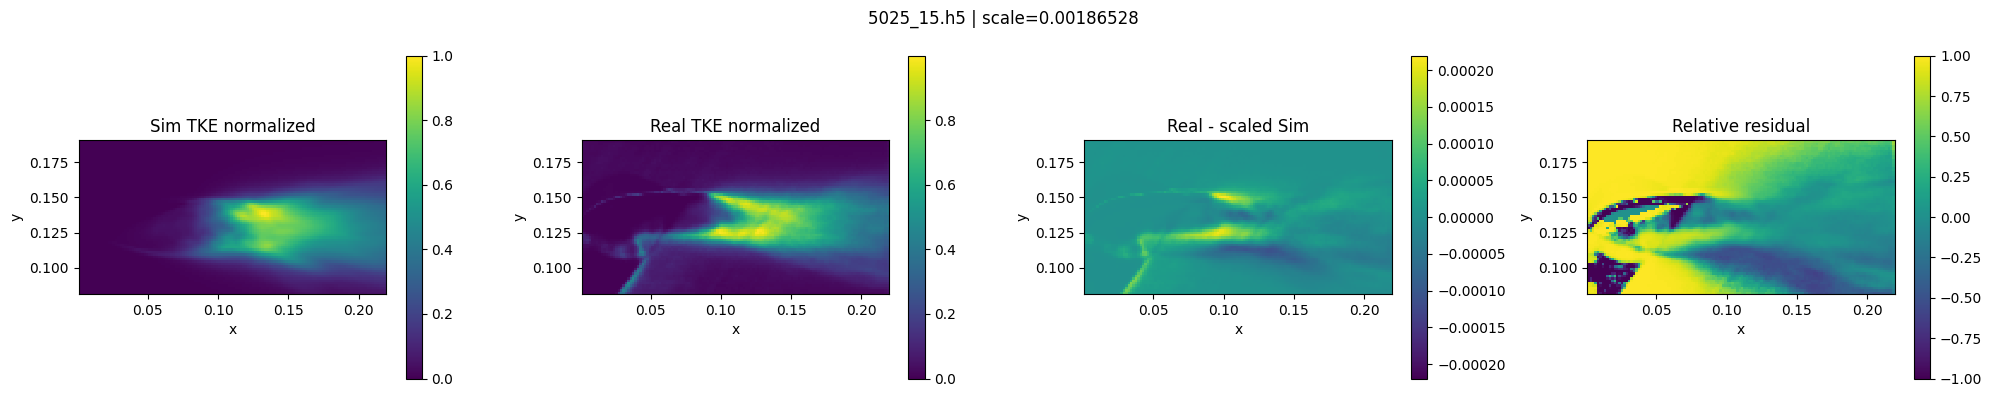

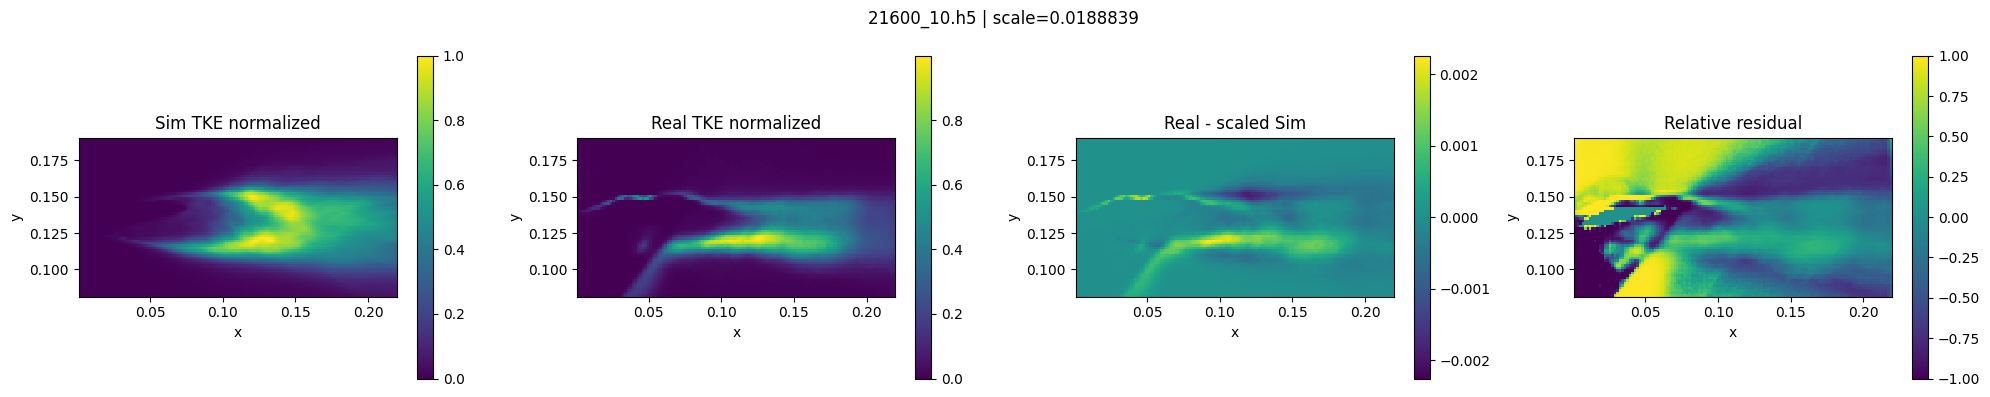

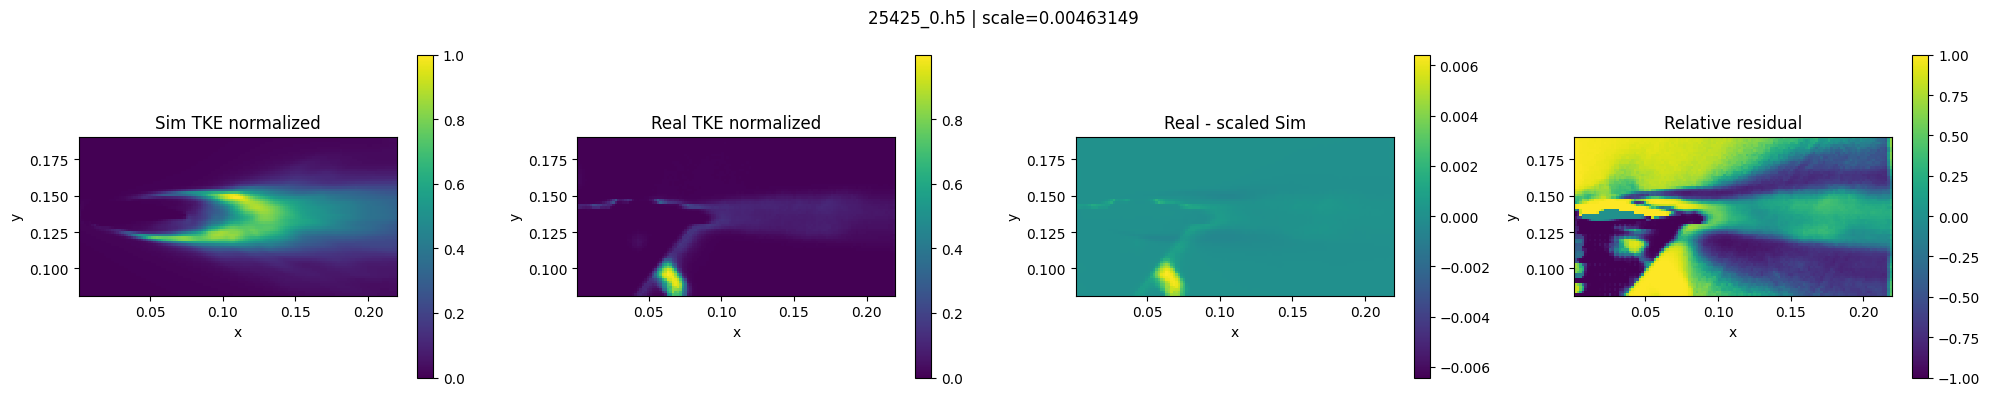

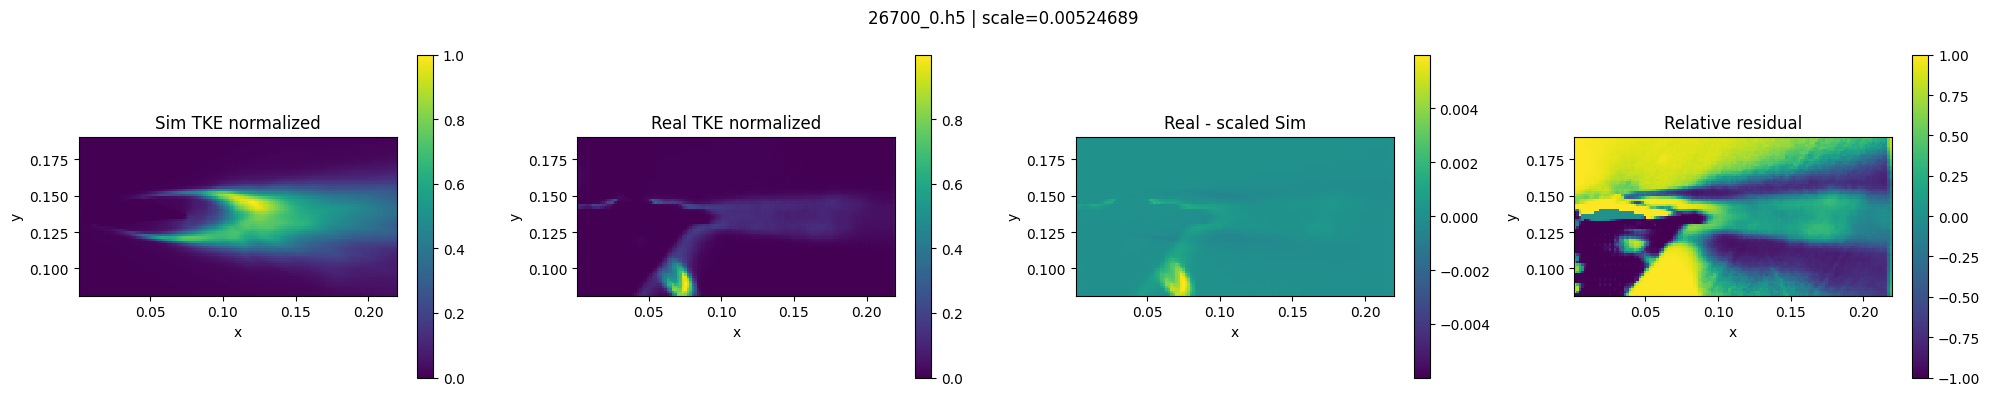

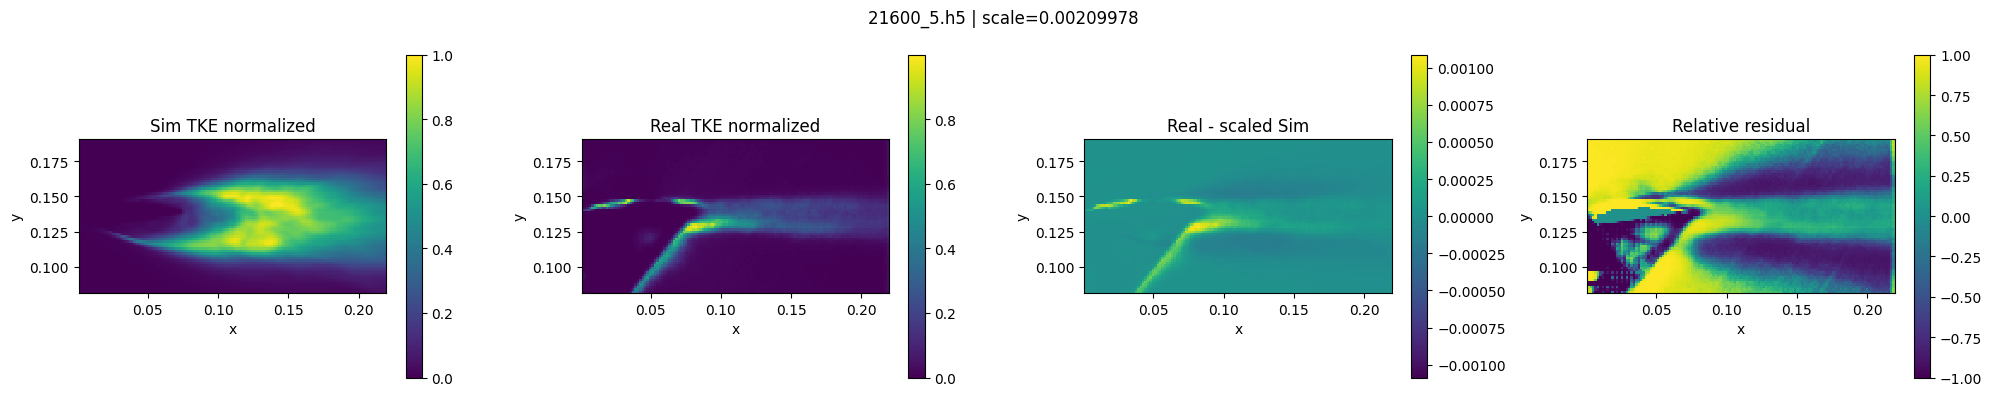

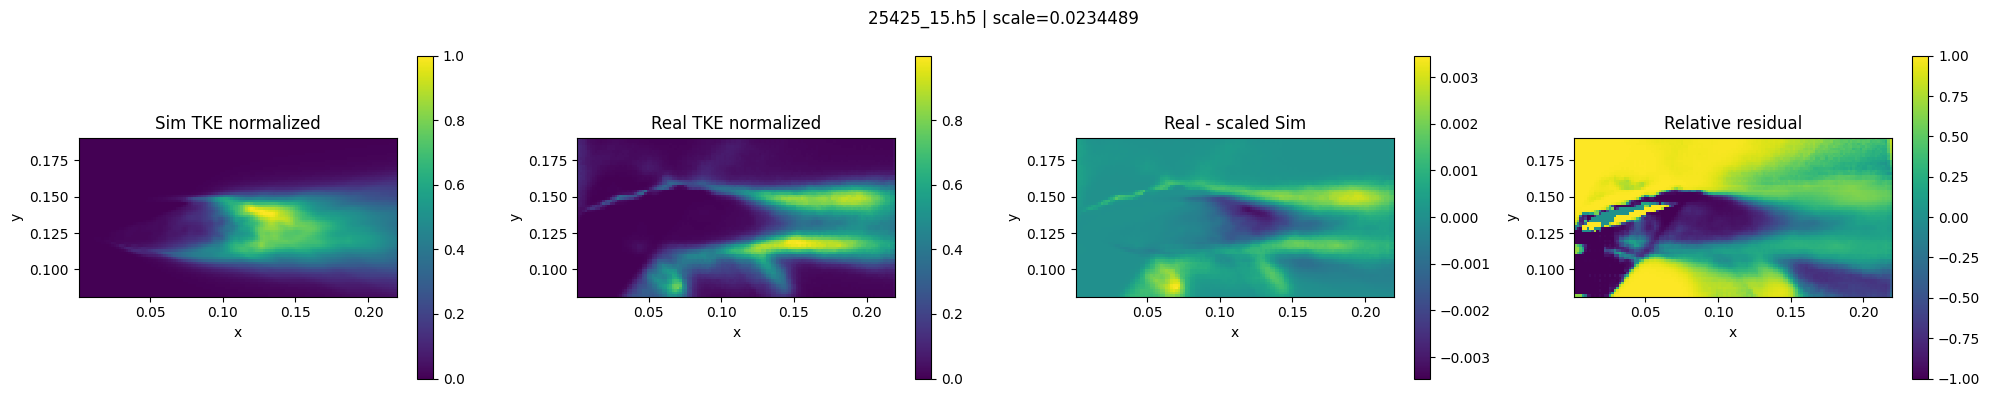

In [11]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

FILES = [
    "5025_15.h5",
    "21600_10.h5",
    "25425_0.h5",
    "26700_0.h5",
    "21600_5.h5",
    "25425_15.h5",
]

def tke(u, v):
    um = u.mean(0)
    vm = v.mean(0)

    return 0.5 * (
        np.mean((u-um)**2, axis=0)
        +
        np.mean((v-vm)**2, axis=0)
    )

def fit_scale(x, y):
    x = x.ravel()
    y = y.ravel()
    return np.dot(x,y) / np.dot(x,x)

for fname in FILES:

    with h5py.File(os.path.join(path_real,fname),"r") as fr, \
         h5py.File(os.path.join(path_sim,fname),"r") as fs:

        kr = tke(
            fr["u"][:].astype(np.float64),
            fr["v"][:].astype(np.float64)
        )

        ks = tke(
            fs["u"][:].astype(np.float64),
            fs["v"][:].astype(np.float64)
        )

        x = fr["x"][:]
        y = fr["y"][:]

        a = fit_scale(ks,kr)
        pred = a*ks
        residual = kr-pred

        # normalized maps: compare SHAPE
        krn = kr / (np.max(kr)+1e-12)
        ksn = ks / (np.max(ks)+1e-12)

        fig, axes = plt.subplots(
            1,4,
            figsize=(20,4)
        )

        im = axes[0].pcolormesh(
            x,y,ksn,
            shading="auto"
        )
        axes[0].set_title("Sim TKE normalized")
        plt.colorbar(im,ax=axes[0])

        im = axes[1].pcolormesh(
            x,y,krn,
            shading="auto"
        )
        axes[1].set_title("Real TKE normalized")
        plt.colorbar(im,ax=axes[1])

        vmax = max(
            np.max(np.abs(residual)),
            1e-12
        )

        im = axes[2].pcolormesh(
            x,y,residual,
            shading="auto",
            vmin=-vmax,
            vmax=vmax
        )
        axes[2].set_title("Real - scaled Sim")
        plt.colorbar(im,ax=axes[2])

        # relative local mismatch
        relative = residual / (
            kr + pred + 1e-10
        )

        im = axes[3].pcolormesh(
            x,y,relative,
            shading="auto",
            vmin=-1,
            vmax=1
        )
        axes[3].set_title(
            "Relative residual"
        )
        plt.colorbar(im,ax=axes[3])

        for ax in axes:
            ax.set_aspect("equal")
            ax.set_xlabel("x")
            ax.set_ylabel("y")

        fig.suptitle(
            f"{fname} | scale={a:.6g}"
        )

        plt.tight_layout()
        plt.show()

In [12]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.ndimage import binary_dilation

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

DILATIONS = [0, 1, 2, 4, 8]


def get_tke(u, v):
    um = u.mean(0)
    vm = v.mean(0)

    return 0.5 * (
        np.mean((u - um)**2, axis=0)
        +
        np.mean((v - vm)**2, axis=0)
    )


def corr_masked(a, b, mask):
    x = a[mask]
    y = b[mask]

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) < 10:
        return np.nan

    return float(np.corrcoef(x, y)[0,1])


def scale_fit_masked(sim, real, mask):
    x = sim[mask]
    y = real[mask]

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    denom = np.dot(x, x)

    if denom == 0:
        return np.nan

    return float(np.dot(x,y) / denom)


def rel_l2_masked(real, pred, mask):
    y = real[mask]
    p = pred[mask]

    good = np.isfinite(y) & np.isfinite(p)
    y = y[good]
    p = p[good]

    denom = np.linalg.norm(y)

    if denom == 0:
        return np.nan

    return float(np.linalg.norm(y-p) / denom)


rows = []

for i, fname in enumerate(files):

    with h5py.File(os.path.join(path_real,fname),"r") as fr, \
         h5py.File(os.path.join(path_sim,fname),"r") as fs:

        ur = fr["u"][:].astype(np.float64)
        vr = fr["v"][:].astype(np.float64)

        us = fs["u"][:].astype(np.float64)
        vs = fs["v"][:].astype(np.float64)

        kr = get_tke(ur,vr)
        ks = get_tke(us,vs)

        # ----------------------------------------------------
        # Candidate solid/invalid region
        #
        # A point is considered solid-like if BOTH time-mean
        # velocity components are essentially zero.
        #
        # We use union of Real + Sim candidates deliberately.
        # ----------------------------------------------------

        umr = ur.mean(0)
        vmr = vr.mean(0)

        ums = us.mean(0)
        vms = vs.mean(0)

        eps_r = 1e-10
        eps_s = 1e-10

        solid_r = (
            (np.abs(umr) < eps_r)
            &
            (np.abs(vmr) < eps_r)
        )

        solid_s = (
            (np.abs(ums) < eps_s)
            &
            (np.abs(vms) < eps_s)
        )

        solid = solid_r | solid_s

        for d in DILATIONS:

            if d == 0:
                excluded = solid
            else:
                excluded = binary_dilation(
                    solid,
                    iterations=d
                )

            valid = ~excluded

            a = scale_fit_masked(
                ks, kr, valid
            )

            pred = a * ks

            rows.append({
                "file": fname,
                "Re": int(fr["re"][()]),
                "AoA": int(fr["aoa"][()]),
                "dilation": d,

                "excluded_fraction":
                    float(excluded.mean()),

                "corr":
                    corr_masked(
                        kr, ks, valid
                    ),

                "scale":
                    a,

                "scaled_relL2":
                    rel_l2_masked(
                        kr, pred, valid
                    ),
            })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)

print("\n" + "="*100)
print("GLOBAL BY DISTANCE FROM SOLID")
print("="*100)

print(
    df.groupby("dilation")[
        [
            "excluded_fraction",
            "corr",
            "scaled_relL2"
        ]
    ]
    .agg(["mean","median"])
    .to_string()
)


print("\n" + "="*100)
print("BY AoA")
print("="*100)

print(
    df.groupby(
        ["AoA","dilation"]
    )[
        ["corr","scaled_relL2"]
    ]
    .mean()
    .to_string()
)


TARGETS = [
    "5025_15.h5",
    "21600_10.h5",
    "25425_0.h5",
    "26700_0.h5",
    "21600_5.h5",
    "25425_15.h5",
]

print("\n" + "="*100)
print("TARGET FILES")
print("="*100)

print(
    df[df["file"].isin(TARGETS)]
    .sort_values(
        ["file","dilation"]
    )
    .to_string(index=False)
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL BY DISTANCE FROM SOLID
         excluded_fraction                corr           scaled_relL2          
                      mean    median      mean    median         mean    median
dilation                                                                       
0                 0.037121  0.036255  0.661733  0.706028     0.628364  0.601393
1                 0.055610  0.056885  0.659334  0.704424     0.628152  0.601386
2                 0.072225  0.074402  0.658195  0.703264     0.627285  0.601250
4                 0.102287  0.105347  0.660127  0.704249     0.622918  0.597991
8                 0.157133  0.158569  0.661098  0.705248     0.616657  0.589269

BY AoA
                  corr  scaled_relL2
AoA dilation                        
0   0         0.514150      0.763597
    1         0.512980      0.762817
    2         0.515816      0.759504
    4         0.525497      0.750348
    8         0.529794      0.74374

In [13]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

# Real dt ≈ 0.02, Sim dt ≈ 0.02002
# Compare by approximately equal physical lag.
LAG_TIMES = [
    0.02,
    0.04,
    0.10,
    0.20,
    0.40,
    1.00,
    2.00,
    4.00,
]

EPS = 1e-12

# To keep computation manageable and avoid correlated neighboring pixels
# dominating, sample spatial locations regularly.
SPATIAL_STRIDE = 2

rng = np.random.default_rng(42)


def prepare_channel(arr):
    """
    arr: [T,H,W]

    Returns:
        fluctuation field
        standardized fluctuation per pixel
        valid spatial mask
    """
    arr = arr.astype(np.float64)

    mean = arr.mean(axis=0)
    fluc = arr - mean

    std = fluc.std(axis=0)

    # Ignore essentially constant pixels.
    valid = np.isfinite(std) & (std > EPS)

    z = np.zeros_like(fluc)
    z[:, valid] = fluc[:, valid] / std[valid]

    return fluc, z, valid


def mean_pixel_autocorr(z, valid, lag):
    """
    Mean temporal correlation across spatial pixels.
    Because z is standardized using whole trajectory,
    compute centered correlation on each lagged segment.
    """

    if lag <= 0 or lag >= len(z):
        return np.nan

    a = z[:-lag, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]
    b = z[ lag:, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

    vm = valid[::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

    a = a[:, vm]
    b = b[:, vm]

    if a.shape[1] == 0:
        return np.nan

    # Center each pixel over overlapping segment.
    a = a - a.mean(axis=0, keepdims=True)
    b = b - b.mean(axis=0, keepdims=True)

    num = np.sum(a*b, axis=0)

    den = np.sqrt(
        np.sum(a*a, axis=0)
        *
        np.sum(b*b, axis=0)
    )

    good = den > EPS

    if good.sum() == 0:
        return np.nan

    c = num[good] / den[good]

    return float(np.mean(c))


def persistence_rel_l2(fluc, valid, lag):
    """
    Copy-current-frame baseline:
        prediction(t+lag) = current(t)
    """

    if lag <= 0 or lag >= len(fluc):
        return np.nan

    a = fluc[:-lag, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]
    y = fluc[ lag:, ::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

    vm = valid[::SPATIAL_STRIDE, ::SPATIAL_STRIDE]

    a = a[:, vm]
    y = y[:, vm]

    denom = np.linalg.norm(y)

    if denom < EPS:
        return np.nan

    return float(
        np.linalg.norm(y-a) / denom
    )


def shuffled_null_corr(z, valid, lag, n_shuffle=5):
    """
    Destroy temporal ordering while preserving marginal distribution.
    Gives null correlation scale.
    """

    vals = []

    T = len(z)

    for _ in range(n_shuffle):

        perm = rng.permutation(T)
        zp = z[perm]

        vals.append(
            mean_pixel_autocorr(
                zp,
                valid,
                lag
            )
        )

    return float(np.nanmean(vals))


def physical_lag_to_frames(t, lag_time):
    dt = float(np.median(np.diff(t)))

    frames = int(round(lag_time / dt))

    return max(frames, 1)


rows = []

for i, fname in enumerate(files):

    with h5py.File(
        os.path.join(path_real, fname),
        "r"
    ) as fr, h5py.File(
        os.path.join(path_sim, fname),
        "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        tr = fr["t"][:].astype(np.float64)
        ts = fs["t"][:].astype(np.float64)

        ur = fr["u"][:]
        vr = fr["v"][:]

        us = fs["u"][:]
        vs = fs["v"][:]

        datasets = {
            ("Real","u"): (ur,tr),
            ("Real","v"): (vr,tr),
            ("Sim","u"):  (us,ts),
            ("Sim","v"):  (vs,ts),
        }

        for (domain,channel), (arr,t) in datasets.items():

            fluc, z, valid = prepare_channel(arr)

            for lag_time in LAG_TIMES:

                lag = physical_lag_to_frames(
                    t,
                    lag_time
                )

                if lag >= len(arr):
                    continue

                ac = mean_pixel_autocorr(
                    z,
                    valid,
                    lag
                )

                null_ac = shuffled_null_corr(
                    z,
                    valid,
                    lag
                )

                persist = persistence_rel_l2(
                    fluc,
                    valid,
                    lag
                )

                rows.append({
                    "file": fname,
                    "Re": Re,
                    "AoA": AoA,
                    "domain": domain,
                    "channel": channel,

                    "lag_time_requested":
                        lag_time,

                    "lag_frames":
                        lag,

                    "actual_lag_time":
                        lag * float(
                            np.median(
                                np.diff(t)
                            )
                        ),

                    "autocorr":
                        ac,

                    "null_autocorr":
                        null_ac,

                    "autocorr_minus_null":
                        ac-null_ac,

                    "persistence_relL2":
                        persist,

                    "valid_fraction":
                        float(valid.mean()),
                })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)


# ============================================================
# 1. GLOBAL AUTOCORRELATION CURVES
# ============================================================

print("\n" + "="*110)
print("GLOBAL TEMPORAL AUTOCORRELATION")
print("="*110)

global_summary = (
    df.groupby(
        [
            "domain",
            "channel",
            "lag_time_requested"
        ]
    )[
        [
            "autocorr",
            "null_autocorr",
            "autocorr_minus_null",
            "persistence_relL2"
        ]
    ]
    .agg(["mean","median","std"])
)

print(global_summary.to_string())


# ============================================================
# 2. REAL-SIM CURVE DIFFERENCE
# ============================================================

print("\n" + "="*110)
print("REAL VS SIM AUTOCORRELATION DIFFERENCE")
print("="*110)

mean_curves = (
    df.groupby(
        [
            "domain",
            "channel",
            "lag_time_requested"
        ]
    )["autocorr"]
    .mean()
    .reset_index()
)

for channel in ["u","v"]:

    r = (
        mean_curves[
            (mean_curves.domain=="Real")
            &
            (mean_curves.channel==channel)
        ]
        .set_index("lag_time_requested")
        ["autocorr"]
    )

    s = (
        mean_curves[
            (mean_curves.domain=="Sim")
            &
            (mean_curves.channel==channel)
        ]
        .set_index("lag_time_requested")
        ["autocorr"]
    )

    common = r.index.intersection(s.index)

    out = pd.DataFrame({
        "Real": r.loc[common],
        "Sim": s.loc[common],
    })

    out["difference"] = (
        out["Real"] - out["Sim"]
    )

    print("\nCHANNEL", channel)
    print(out.to_string())


# ============================================================
# 3. BY AoA
# ============================================================

print("\n" + "="*110)
print("AUTOCORRELATION BY AoA")
print("="*110)

by_aoa = (
    df.groupby(
        [
            "AoA",
            "domain",
            "channel",
            "lag_time_requested"
        ]
    )["autocorr"]
    .mean()
)

print(by_aoa.to_string())


# ============================================================
# 4. REPRESENTATIVE FILES
# ============================================================

targets = [
    "3750_0.h5",
    "5025_15.h5",
    "13950_15.h5",
    "21600_5.h5",
    "21600_10.h5",
    "25425_0.h5",
    "25425_15.h5",
    "26700_0.h5",
]

print("\n" + "="*110)
print("REPRESENTATIVE FILES")
print("="*110)

print(
    df[df["file"].isin(targets)]
    [
        [
            "file",
            "Re",
            "AoA",
            "domain",
            "channel",
            "lag_time_requested",
            "autocorr",
            "null_autocorr",
            "persistence_relL2"
        ]
    ]
    .sort_values(
        [
            "file",
            "domain",
            "channel",
            "lag_time_requested"
        ]
    )
    .to_string(index=False)
)


# ============================================================
# 5. Estimate decorrelation time
#
# First requested lag at which C(tau) <= 1/e.
# This is a coarse estimate only.
# ============================================================

threshold = 1/np.e

decor_rows = []

for keys, g in df.groupby(
    ["file","Re","AoA","domain","channel"]
):

    g = g.sort_values(
        "lag_time_requested"
    )

    below = g[
        g["autocorr"] <= threshold
    ]

    if len(below) > 0:
        tau = float(
            below.iloc[0][
                "actual_lag_time"
            ]
        )
    else:
        tau = np.nan

    decor_rows.append({
        "file": keys[0],
        "Re": keys[1],
        "AoA": keys[2],
        "domain": keys[3],
        "channel": keys[4],
        "decorrelation_time_1_over_e":
            tau,
    })

decor = pd.DataFrame(decor_rows)

print("\n" + "="*110)
print("DECORRELATION TIME SUMMARY")
print("="*110)

print(
    decor.groupby(
        ["domain","channel"]
    )[
        "decorrelation_time_1_over_e"
    ]
    .describe()
    .to_string()
)


print("\n" + "="*110)
print("DECORRELATION TIME BY AoA")
print("="*110)

print(
    decor.groupby(
        [
            "AoA",
            "domain",
            "channel"
        ]
    )[
        "decorrelation_time_1_over_e"
    ]
    .mean()
    .to_string()
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL TEMPORAL AUTOCORRELATION
                                   autocorr                     null_autocorr                     autocorr_minus_null                     persistence_relL2                    
                                       mean    median       std          mean    median       std                mean    median       std              mean    median       std
domain channel lag_time_requested                                                                                                                                              
Real   u       0.02                0.865927  0.866242  0.033021     -0.001251 -0.001210  0.002634            0.867178  0.867925  0.032808          0.404823  0.402489  0.095224
               0.04                0.692692  0.685365  0.070088     -0.001313 -0.001256  0.002564            0.694005  0.683057  0.070728          0.673708  0.682219  0.146805
               0.10    

In [1]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

WINDOWS = [1, 3, 5, 9, 15]

LAG_TIMES = [
    0.02,
    0.04,
    0.06,
    0.10,
    0.20,
    0.40
]

STRIDE = 2
EPS = 1e-12


def moving_average(arr, w):

    if w == 1:
        return arr.astype(np.float64)

    arr = arr.astype(np.float64)

    cs = np.cumsum(
        arr,
        axis=0,
        dtype=np.float64
    )

    cs = np.concatenate(
        [
            np.zeros_like(cs[:1]),
            cs
        ],
        axis=0
    )

    return (
        cs[w:] - cs[:-w]
    ) / w


def prepare(arr):

    mean = arr.mean(axis=0)
    fluc = arr - mean

    std = fluc.std(axis=0)

    valid = (
        np.isfinite(std)
        &
        (std > EPS)
    )

    return fluc, valid


def pixel_autocorr(fluc, valid, lag):

    if lag >= len(fluc):
        return np.nan

    a = fluc[
        :-lag,
        ::STRIDE,
        ::STRIDE
    ]

    b = fluc[
        lag:,
        ::STRIDE,
        ::STRIDE
    ]

    vm = valid[
        ::STRIDE,
        ::STRIDE
    ]

    a = a[:,vm]
    b = b[:,vm]

    # correlation independently for each pixel
    a = a - a.mean(
        axis=0,
        keepdims=True
    )

    b = b - b.mean(
        axis=0,
        keepdims=True
    )

    num = np.sum(a*b,axis=0)

    den = np.sqrt(
        np.sum(a*a,axis=0)
        *
        np.sum(b*b,axis=0)
    )

    good = den > EPS

    if not np.any(good):
        return np.nan

    return float(
        np.mean(
            num[good]/den[good]
        )
    )


rows = []

for idx,fname in enumerate(files):

    with h5py.File(
        os.path.join(path_real,fname),
        "r"
    ) as fr, \
    h5py.File(
        os.path.join(path_sim,fname),
        "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        datasets = [
            (
                "Real",
                fr["u"][:],
                fr["v"][:],
                fr["t"][:]
            ),
            (
                "Sim",
                fs["u"][:],
                fs["v"][:],
                fs["t"][:]
            )
        ]

        for domain,u,v,t in datasets:

            dt = float(
                np.median(
                    np.diff(t)
                )
            )

            for channel,arr in [
                ("u",u),
                ("v",v)
            ]:

                for w in WINDOWS:

                    sm = moving_average(
                        arr,
                        w
                    )

                    fluc,valid = prepare(sm)

                    for tau in LAG_TIMES:

                        lag = max(
                            1,
                            int(round(
                                tau/dt
                            ))
                        )

                        if lag >= len(sm):
                            continue

                        ac = pixel_autocorr(
                            fluc,
                            valid,
                            lag
                        )

                        rows.append({
                            "file":fname,
                            "Re":Re,
                            "AoA":AoA,
                            "domain":domain,
                            "channel":channel,
                            "window":w,
                            "window_time":
                                w*dt,
                            "lag_time":tau,
                            "autocorr":ac
                        })

    if (idx+1)%10 == 0:
        print(
            idx+1,
            "/",
            len(files)
        )


df = pd.DataFrame(rows)


# ==========================================================
# GLOBAL
# ==========================================================

summary = (
    df.groupby(
        [
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .agg(["mean","median","std"])
)

print("\n"+"="*100)
print("GLOBAL")
print("="*100)

print(summary.to_string())


# ==========================================================
# REAL-SIM GAP
# ==========================================================

means = (
    df.groupby(
        [
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .mean()
    .reset_index()
)

pivot = means.pivot_table(
    index=[
        "channel",
        "window",
        "lag_time"
    ],
    columns="domain",
    values="autocorr"
)

pivot["gap_R_minus_S"] = (
    pivot["Real"]
    -
    pivot["Sim"]
)

print("\n"+"="*100)
print("REAL - SIM GAP")
print("="*100)

print(pivot.to_string())


# ==========================================================
# NORMALIZED DECAY
#
# Normalize each curve by its first-lag correlation.
# This removes much of pure amplitude attenuation.
# ==========================================================

curve = means.copy()

curve["normalized"] = np.nan

for keys,g in curve.groupby(
    ["domain","channel","window"]
):

    g = g.sort_values("lag_time")

    base = g.iloc[0]["autocorr"]

    curve.loc[
        g.index,
        "normalized"
    ] = (
        g["autocorr"] / base
    )


normpivot = curve.pivot_table(
    index=[
        "channel",
        "window",
        "lag_time"
    ],
    columns="domain",
    values="normalized"
)

normpivot["gap"] = (
    normpivot["Real"]
    -
    normpivot["Sim"]
)

print("\n"+"="*100)
print("NORMALIZED DECAY")
print("="*100)

print(normpivot.to_string())


# ==========================================================
# ONE NUMBER PER WINDOW:
# mean |Real-Sim| normalized-curve discrepancy
# ==========================================================

discrepancy = (
    normpivot
    .reset_index()
    .groupby(
        ["channel","window"]
    )["gap"]
    .apply(
        lambda x:
        np.mean(np.abs(x))
    )
)

print("\n"+"="*100)
print("NORMALIZED CURVE DISCREPANCY")
print("="*100)

print(discrepancy.to_string())


# ==========================================================
# BY AoA
# ==========================================================

aoa = (
    df.groupby(
        [
            "AoA",
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .mean()
)

print("\n"+"="*100)
print("BY AoA")
print("="*100)

print(aoa.to_string())

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL
                                    mean    median       std
domain channel window lag_time                              
Real   u       1      0.02      0.865930  0.866242  0.033023
                      0.04      0.692697  0.685365  0.070091
                      0.06      0.506665  0.485008  0.105690
                      0.10      0.273359  0.235360  0.136969
                      0.20      0.133452  0.125537  0.120174
                      0.40      0.063471  0.062604  0.067413
               3      0.02      0.934494  0.932116  0.015363
                      0.04      0.775365  0.766802  0.051174
                      0.06      0.585304  0.568666  0.090611
                      0.10      0.321375  0.284774  0.133493
                      0.20      0.149114  0.140804  0.125123
                      0.40      0.073162  0.071055  0.072734
               5      0.02      0.958314  0.956507  0.009462
             

In [1]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

WINDOWS = [1, 3, 5, 9, 15]

LAG_TIMES = [
    0.02,
    0.04,
    0.06,
    0.10,
    0.20,
    0.40
]

STRIDE = 2
EPS = 1e-12


def moving_average(arr, w):

    if w == 1:
        return arr.astype(np.float64)

    arr = arr.astype(np.float64)

    cs = np.cumsum(
        arr,
        axis=0,
        dtype=np.float64
    )

    cs = np.concatenate(
        [
            np.zeros_like(cs[:1]),
            cs
        ],
        axis=0
    )

    return (
        cs[w:] - cs[:-w]
    ) / w


def prepare(arr):

    mean = arr.mean(axis=0)
    fluc = arr - mean

    std = fluc.std(axis=0)

    valid = (
        np.isfinite(std)
        &
        (std > EPS)
    )

    return fluc, valid


def pixel_autocorr(fluc, valid, lag):

    if lag >= len(fluc):
        return np.nan

    a = fluc[
        :-lag,
        ::STRIDE,
        ::STRIDE
    ]

    b = fluc[
        lag:,
        ::STRIDE,
        ::STRIDE
    ]

    vm = valid[
        ::STRIDE,
        ::STRIDE
    ]

    a = a[:,vm]
    b = b[:,vm]

    # correlation independently for each pixel
    a = a - a.mean(
        axis=0,
        keepdims=True
    )

    b = b - b.mean(
        axis=0,
        keepdims=True
    )

    num = np.sum(a*b,axis=0)

    den = np.sqrt(
        np.sum(a*a,axis=0)
        *
        np.sum(b*b,axis=0)
    )

    good = den > EPS

    if not np.any(good):
        return np.nan

    return float(
        np.mean(
            num[good]/den[good]
        )
    )


rows = []

for idx,fname in enumerate(files):

    with h5py.File(
        os.path.join(path_real,fname),
        "r"
    ) as fr, \
    h5py.File(
        os.path.join(path_sim,fname),
        "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        datasets = [
            (
                "Real",
                fr["u"][:],
                fr["v"][:],
                fr["t"][:]
            ),
            (
                "Sim",
                fs["u"][:],
                fs["v"][:],
                fs["t"][:]
            )
        ]

        for domain,u,v,t in datasets:

            dt = float(
                np.median(
                    np.diff(t)
                )
            )

            for channel,arr in [
                ("u",u),
                ("v",v)
            ]:

                for w in WINDOWS:

                    sm = moving_average(
                        arr,
                        w
                    )

                    fluc,valid = prepare(sm)

                    for tau in LAG_TIMES:

                        lag = max(
                            1,
                            int(round(
                                tau/dt
                            ))
                        )

                        if lag >= len(sm):
                            continue

                        ac = pixel_autocorr(
                            fluc,
                            valid,
                            lag
                        )

                        rows.append({
                            "file":fname,
                            "Re":Re,
                            "AoA":AoA,
                            "domain":domain,
                            "channel":channel,
                            "window":w,
                            "window_time":
                                w*dt,
                            "lag_time":tau,
                            "autocorr":ac
                        })

    if (idx+1)%10 == 0:
        print(
            idx+1,
            "/",
            len(files)
        )


df = pd.DataFrame(rows)


# ==========================================================
# GLOBAL
# ==========================================================

summary = (
    df.groupby(
        [
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .agg(["mean","median","std"])
)

print("\n"+"="*100)
print("GLOBAL")
print("="*100)

print(summary.to_string())


# ==========================================================
# REAL-SIM GAP
# ==========================================================

means = (
    df.groupby(
        [
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .mean()
    .reset_index()
)

pivot = means.pivot_table(
    index=[
        "channel",
        "window",
        "lag_time"
    ],
    columns="domain",
    values="autocorr"
)

pivot["gap_R_minus_S"] = (
    pivot["Real"]
    -
    pivot["Sim"]
)

print("\n"+"="*100)
print("REAL - SIM GAP")
print("="*100)

print(pivot.to_string())


# ==========================================================
# NORMALIZED DECAY
#
# Normalize each curve by its first-lag correlation.
# This removes much of pure amplitude attenuation.
# ==========================================================

curve = means.copy()

curve["normalized"] = np.nan

for keys,g in curve.groupby(
    ["domain","channel","window"]
):

    g = g.sort_values("lag_time")

    base = g.iloc[0]["autocorr"]

    curve.loc[
        g.index,
        "normalized"
    ] = (
        g["autocorr"] / base
    )


normpivot = curve.pivot_table(
    index=[
        "channel",
        "window",
        "lag_time"
    ],
    columns="domain",
    values="normalized"
)

normpivot["gap"] = (
    normpivot["Real"]
    -
    normpivot["Sim"]
)

print("\n"+"="*100)
print("NORMALIZED DECAY")
print("="*100)

print(normpivot.to_string())


# ==========================================================
# ONE NUMBER PER WINDOW:
# mean |Real-Sim| normalized-curve discrepancy
# ==========================================================

discrepancy = (
    normpivot
    .reset_index()
    .groupby(
        ["channel","window"]
    )["gap"]
    .apply(
        lambda x:
        np.mean(np.abs(x))
    )
)

print("\n"+"="*100)
print("NORMALIZED CURVE DISCREPANCY")
print("="*100)

print(discrepancy.to_string())


# ==========================================================
# BY AoA
# ==========================================================

aoa = (
    df.groupby(
        [
            "AoA",
            "domain",
            "channel",
            "window",
            "lag_time"
        ]
    )["autocorr"]
    .mean()
)

print("\n"+"="*100)
print("BY AoA")
print("="*100)

print(aoa.to_string())

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL
                                    mean    median       std
domain channel window lag_time                              
Real   u       1      0.02      0.865930  0.866242  0.033023
                      0.04      0.692697  0.685365  0.070091
                      0.06      0.506665  0.485008  0.105690
                      0.10      0.273359  0.235360  0.136969
                      0.20      0.133452  0.125537  0.120174
                      0.40      0.063471  0.062604  0.067413
               3      0.02      0.934494  0.932116  0.015363
                      0.04      0.775365  0.766802  0.051174
                      0.06      0.585304  0.568666  0.090611
                      0.10      0.321375  0.284774  0.133493
                      0.20      0.149114  0.140804  0.125123
                      0.40      0.073162  0.071055  0.072734
               5      0.02      0.958314  0.956507  0.009462
             

In [1]:
import os
import h5py
import numpy as np
import pandas as pd

path_real = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real'
path_sim  = '/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim'

files = sorted([
    f for f in os.listdir(path_real)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(path_sim, f))
])

WINDOWS = [5, 9, 15]
LAGS = [1, 2, 3, 5, 10]
STRIDE = 2
EPS = 1e-12


def centered_decompose(arr, w):
    """
    Returns aligned:
        original_center
        slow
        fast = original_center - slow

    w must be odd.
    """
    assert w % 2 == 1

    arr = arr.astype(np.float64)

    half = w // 2

    cs = np.cumsum(arr, axis=0, dtype=np.float64)
    cs = np.concatenate(
        [np.zeros_like(cs[:1]), cs],
        axis=0
    )

    slow = (cs[w:] - cs[:-w]) / w

    original = arr[half:-half]

    assert len(original) == len(slow)

    fast = original - slow

    return original, slow, fast


def temporal_corr(arr, lag):
    """
    Mean per-pixel temporal correlation.
    """
    if lag >= len(arr):
        return np.nan

    x = arr[:-lag, ::STRIDE, ::STRIDE]
    y = arr[lag:, ::STRIDE, ::STRIDE]

    x = x - x.mean(axis=0, keepdims=True)
    y = y - y.mean(axis=0, keepdims=True)

    num = np.sum(x*y, axis=0)

    den = np.sqrt(
        np.sum(x*x, axis=0)
        *
        np.sum(y*y, axis=0)
    )

    good = (
        np.isfinite(den)
        &
        (den > EPS)
    )

    if not np.any(good):
        return np.nan

    return float(
        np.mean(
            num[good] / den[good]
        )
    )


def variance_energy(arr):
    """
    Mean temporal variance across spatial pixels.
    """
    return float(
        np.mean(
            np.var(
                arr,
                axis=0
            )
        )
    )


rows = []

for i, fname in enumerate(files):

    with h5py.File(
        os.path.join(path_real, fname), "r"
    ) as fr, h5py.File(
        os.path.join(path_sim, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, f in [
            ("Real", fr),
            ("Sim", fs)
        ]:

            dt = float(
                np.median(
                    np.diff(f["t"][:])
                )
            )

            for channel in ["u", "v"]:

                arr = f[channel][:]

                for w in WINDOWS:

                    original, slow, fast = centered_decompose(
                        arr, w
                    )

                    var_original = variance_energy(original)
                    var_slow = variance_energy(slow)
                    var_fast = variance_energy(fast)

                    fast_fraction = (
                        var_fast / var_original
                        if var_original > EPS
                        else np.nan
                    )

                    slow_fraction = (
                        var_slow / var_original
                        if var_original > EPS
                        else np.nan
                    )

                    for lag in LAGS:

                        rows.append({
                            "file": fname,
                            "Re": Re,
                            "AoA": AoA,
                            "domain": domain,
                            "channel": channel,
                            "window": w,
                            "window_time": w * dt,
                            "lag_frames": lag,
                            "lag_time": lag * dt,

                            "corr_original":
                                temporal_corr(
                                    original,
                                    lag
                                ),

                            "corr_slow":
                                temporal_corr(
                                    slow,
                                    lag
                                ),

                            "corr_fast":
                                temporal_corr(
                                    fast,
                                    lag
                                ),

                            "var_original":
                                var_original,

                            "var_slow":
                                var_slow,

                            "var_fast":
                                var_fast,

                            "fast_var_fraction":
                                fast_fraction,

                            "slow_var_fraction":
                                slow_fraction,
                        })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)


# ============================================================
# 1. FAST RESIDUAL AUTOCORRELATION
# ============================================================

fast_ac = (
    df.groupby([
        "domain",
        "channel",
        "window",
        "lag_frames"
    ])["corr_fast"]
    .agg(["mean", "median", "std"])
)

print("\n" + "="*100)
print("FAST RESIDUAL AUTOCORRELATION")
print("="*100)
print(fast_ac.to_string())


# ============================================================
# 2. ORIGINAL / SLOW / FAST SIDE BY SIDE
# ============================================================

corr_summary = (
    df.groupby([
        "domain",
        "channel",
        "window",
        "lag_frames"
    ])[
        [
            "corr_original",
            "corr_slow",
            "corr_fast"
        ]
    ]
    .mean()
)

print("\n" + "="*100)
print("ORIGINAL vs SLOW vs FAST")
print("="*100)
print(corr_summary.to_string())


# ============================================================
# 3. VARIANCE FRACTION
# Avoid duplicate rows from different lags
# ============================================================

variance_df = (
    df[
        [
            "file",
            "Re",
            "AoA",
            "domain",
            "channel",
            "window",
            "fast_var_fraction",
            "slow_var_fraction"
        ]
    ]
    .drop_duplicates()
)


variance_summary = (
    variance_df.groupby([
        "domain",
        "channel",
        "window"
    ])[
        [
            "fast_var_fraction",
            "slow_var_fraction"
        ]
    ]
    .agg(["mean", "median", "std"])
)

print("\n" + "="*100)
print("VARIANCE FRACTION")
print("="*100)
print(variance_summary.to_string())


# ============================================================
# 4. REAL FAST FRACTION BY AoA
# ============================================================

real_aoa = (
    variance_df[
        variance_df["domain"] == "Real"
    ]
    .groupby([
        "AoA",
        "channel",
        "window"
    ])["fast_var_fraction"]
    .agg(["mean", "median", "std"])
)

print("\n" + "="*100)
print("REAL FAST VARIANCE FRACTION BY AoA")
print("="*100)
print(real_aoa.to_string())


# ============================================================
# 5. MOST IMPORTANT COMPACT TABLE
# ============================================================

compact_corr = (
    df[
        df["lag_frames"].isin([1, 2, 5])
    ]
    .groupby([
        "domain",
        "channel",
        "window",
        "lag_frames"
    ])["corr_fast"]
    .mean()
    .unstack("lag_frames")
)

compact_var = (
    variance_df
    .groupby([
        "domain",
        "channel",
        "window"
    ])["fast_var_fraction"]
    .mean()
)

compact = compact_corr.join(
    compact_var
)

print("\n" + "="*100)
print("FINAL COMPACT SUMMARY")
print("="*100)
print(compact.to_string())

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

FAST RESIDUAL AUTOCORRELATION
                                      mean    median       std
domain channel window lag_frames                              
Real   u       5      1           0.206492  0.219817  0.048982
                      2          -0.136750 -0.129805  0.034257
                      3          -0.172200 -0.170423  0.017248
                      5          -0.077981 -0.085463  0.039178
                      10          0.000149 -0.001416  0.008697
               9      1           0.574647  0.588266  0.035851
                      2           0.104912  0.114380  0.045711
                      3          -0.302547 -0.298584  0.039893
                      5          -0.335568 -0.337525  0.031946
                      10          0.016465  0.014009  0.018617
               15     1           0.732257  0.743154  0.031638
                      2           0.380733  0.392313  0.049018
                      3

In [2]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.signal import welch

REAL_DIR = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real"
SIM_DIR  = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim"

files = sorted([
    f for f in os.listdir(REAL_DIR)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(SIM_DIR, f))
])

# spatial subsampling only for computation
STRIDE = 2
EPS = 1e-20

# Fractions of Nyquist frequency.
BANDS = [
    (0.00, 0.10),
    (0.10, 0.25),
    (0.25, 0.50),
    (0.50, 0.75),
    (0.75, 1.00),
]


def mean_pixel_psd(arr, dt):
    """
    Remove each pixel's temporal mean, then Welch PSD independently
    for every sampled spatial pixel. Finally average PSD across pixels.
    """
    x = arr[:, ::STRIDE, ::STRIDE].astype(np.float64)

    x -= x.mean(axis=0, keepdims=True)

    T = x.shape[0]
    x = x.reshape(T, -1)

    # Avoid extremely short/long segment differences.
    nperseg = min(256, T)

    f, P = welch(
        x,
        fs=1.0/dt,
        axis=0,
        nperseg=nperseg,
        detrend="constant",
        scaling="density"
    )

    # Mean across spatial pixels.
    Pmean = np.mean(P, axis=1)

    return f, Pmean


def band_fraction(f, P, lo_frac, hi_frac):
    nyq = f[-1]

    lo = lo_frac * nyq
    hi = hi_frac * nyq

    if hi_frac == 1.0:
        mask = (f >= lo) & (f <= hi)
    else:
        mask = (f >= lo) & (f < hi)

    total = np.trapz(P, f)

    if total <= EPS or mask.sum() < 2:
        return np.nan

    band = np.trapz(P[mask], f[mask])

    return float(band / total)


rows = []

# Store normalized spectra for later interpolation/comparison.
spectra = []

for i, fname in enumerate(files):

    with h5py.File(
        os.path.join(REAL_DIR, fname), "r"
    ) as fr, h5py.File(
        os.path.join(SIM_DIR, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, h in [("Real", fr), ("Sim", fs)]:

            t = h["t"][:].astype(np.float64)
            dt = float(np.median(np.diff(t)))

            for channel in ["u", "v"]:

                arr = h[channel][:]

                f, P = mean_pixel_psd(arr, dt)

                total = np.trapz(P, f)

                Pnorm = P / max(total, EPS)

                row = {
                    "file": fname,
                    "Re": Re,
                    "AoA": AoA,
                    "domain": domain,
                    "channel": channel,
                    "dt": dt,
                    "nyquist": f[-1],
                }

                for lo, hi in BANDS:
                    name = f"band_{lo:.2f}_{hi:.2f}"
                    row[name] = band_fraction(
                        f, P, lo, hi
                    )

                rows.append(row)

                # frequency normalized by Nyquist
                spectra.append({
                    "file": fname,
                    "Re": Re,
                    "AoA": AoA,
                    "domain": domain,
                    "channel": channel,
                    "fnorm": f / f[-1],
                    "Pnorm": Pnorm
                })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)

band_cols = [
    f"band_{lo:.2f}_{hi:.2f}"
    for lo, hi in BANDS
]


# ============================================================
# 1. GLOBAL BAND ENERGY
# ============================================================

print("\n" + "="*105)
print("GLOBAL NORMALIZED SPECTRAL ENERGY")
print("="*105)

print(
    df.groupby(
        ["domain", "channel"]
    )[band_cols]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ============================================================
# 2. REAL / SIM RATIO FOR EACH BAND
# ============================================================

means = (
    df.groupby(
        ["domain", "channel"]
    )[band_cols]
    .mean()
)

print("\n" + "="*105)
print("REAL / SIM BAND ENERGY RATIO")
print("="*105)

for ch in ["u", "v"]:

    r = means.loc[("Real", ch)]
    s = means.loc[("Sim", ch)]

    print("\nCHANNEL", ch)

    out = pd.DataFrame({
        "Real": r,
        "Sim": s,
        "Real_over_Sim": r / s
    })

    print(out.to_string())


# ============================================================
# 3. BY AoA
# ============================================================

print("\n" + "="*105)
print("BY AoA — MEAN BAND FRACTIONS")
print("="*105)

aoa = (
    df.groupby(
        ["AoA", "domain", "channel"]
    )[band_cols]
    .mean()
)

print(aoa.to_string())


# ============================================================
# 4. CONTINUOUS NORMALIZED SPECTRAL CURVE
#
# Interpolate every normalized PSD onto same normalized-frequency grid.
# This lets us compare curve shape despite tiny dt difference.
# ============================================================

grid = np.linspace(0, 1, 129)

curve_rows = []

for s in spectra:

    interp = np.interp(
        grid,
        s["fnorm"],
        s["Pnorm"]
    )

    # Renormalize after interpolation.
    area = np.trapz(interp, grid)

    if area > EPS:
        interp /= area

    curve_rows.append({
        "file": s["file"],
        "Re": s["Re"],
        "AoA": s["AoA"],
        "domain": s["domain"],
        "channel": s["channel"],
        "curve": interp
    })


# ============================================================
# 5. Spectral shape discrepancy Real vs Sim
# Same filename, normalized distributions.
# L1 distance:
#
# 0 = identical spectral distribution
# max theoretically ~2
# ============================================================

curve_lookup = {
    (x["file"], x["domain"], x["channel"]):
        x["curve"]
    for x in curve_rows
}

dist_rows = []

for fname in files:

    for ch in ["u", "v"]:

        r = curve_lookup[(fname, "Real", ch)]
        s = curve_lookup[(fname, "Sim", ch)]

        l1 = np.trapz(
            np.abs(r-s),
            grid
        )

        dist_rows.append({
            "file": fname,
            "channel": ch,
            "spectral_L1": float(l1)
        })

dist = pd.DataFrame(dist_rows)

print("\n" + "="*105)
print("SPECTRAL SHAPE DISTANCE")
print("="*105)

print(
    dist.groupby("channel")[
        "spectral_L1"
    ]
    .describe()
    .to_string()
)


# ============================================================
# 6. Most compact result
# ============================================================

print("\n" + "="*105)
print("FINAL COMPACT SUMMARY")
print("="*105)

for ch in ["u", "v"]:

    r = means.loc[("Real", ch)]
    s = means.loc[("Sim", ch)]

    print(f"\nCHANNEL {ch}")

    for col in band_cols:
        print(
            f"{col}: "
            f"Real={r[col]:.6f}, "
            f"Sim={s[col]:.6f}, "
            f"ratio={r[col]/s[col]:.3f}"
        )

    d = dist[
        dist.channel == ch
    ].spectral_L1

    print(
        "spectral_L1: "
        f"mean={d.mean():.6f}, "
        f"median={d.median():.6f}"
    )

/tmp/ipykernel_58/2139253976.py:108: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(P, f)
/tmp/ipykernel_58/2139253976.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total = np.trapz(P, f)
/tmp/ipykernel_58/2139253976.py:76: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  band = np.trapz(P[mask], f[mask])


10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL NORMALIZED SPECTRAL ENERGY
               band_0.00_0.10                     band_0.10_0.25                     band_0.25_0.50                     band_0.50_0.75                     band_0.75_1.00                    
                         mean    median       std           mean    median       std           mean    median       std           mean    median       std           mean    median       std
domain channel                                                                                                                                                                               
Real   u             0.621100  0.619631  0.154741       0.276921  0.280733  0.115097       0.051129  0.043888  0.028853       0.008017  0.006286  0.004908       0.006249  0.004973  0.003673
       v             0.551949  0.435485  0.274860       0.334806  0.284660  0.227912       0.065426  0.021401  0.109106       0.003328  0.001

/tmp/ipykernel_58/2139253976.py:239: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(interp, grid)
/tmp/ipykernel_58/2139253976.py:278: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l1 = np.trapz(


In [3]:
import os
import h5py
import numpy as np
import pandas as pd

REAL_DIR = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real"
SIM_DIR  = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim"

files = sorted([
    f for f in os.listdir(REAL_DIR)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(SIM_DIR, f))
])

STRIDE = 2
EPS = 1e-12
LAGS = [1, 2, 3, 5, 10]


def increment(arr):
    arr = arr.astype(np.float64)
    return np.diff(arr, axis=0)


def mean_pixel_corr(arr, lag):
    if lag >= len(arr):
        return np.nan

    a = arr[:-lag, ::STRIDE, ::STRIDE]
    b = arr[lag:,  ::STRIDE, ::STRIDE]

    a = a.reshape(a.shape[0], -1)
    b = b.reshape(b.shape[0], -1)

    a -= a.mean(axis=0, keepdims=True)
    b -= b.mean(axis=0, keepdims=True)

    num = np.sum(a*b, axis=0)

    den = np.sqrt(
        np.sum(a*a, axis=0) *
        np.sum(b*b, axis=0)
    )

    good = np.isfinite(den) & (den > EPS)

    if not np.any(good):
        return np.nan

    return float(np.mean(num[good] / den[good]))


def variance(arr):
    return float(
        np.mean(
            np.var(arr, axis=0)
        )
    )


rows = []

for i, fname in enumerate(files):

    with h5py.File(
        os.path.join(REAL_DIR, fname), "r"
    ) as fr, h5py.File(
        os.path.join(SIM_DIR, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, h in [
            ("Real", fr),
            ("Sim", fs)
        ]:

            dt = float(
                np.median(
                    np.diff(h["t"][:])
                )
            )

            for channel in ["u", "v"]:

                x = h[channel][:].astype(np.float64)

                # Remove time-mean spatial field.
                x -= x.mean(axis=0, keepdims=True)

                dx = increment(x)

                var_x = variance(x)
                var_dx = variance(dx)

                for lag in LAGS:

                    rows.append({
                        "file": fname,
                        "Re": Re,
                        "AoA": AoA,
                        "domain": domain,
                        "channel": channel,
                        "dt": dt,
                        "lag": lag,
                        "lag_time": lag*dt,

                        "increment_corr":
                            mean_pixel_corr(dx, lag),

                        "increment_var_ratio":
                            var_dx / var_x
                            if var_x > EPS
                            else np.nan
                    })

    if (i+1) % 10 == 0:
        print(i+1, "/", len(files))


df = pd.DataFrame(rows)


# ------------------------------------------------------------
# GLOBAL
# ------------------------------------------------------------

print("\n" + "="*100)
print("GLOBAL INCREMENT AUTOCORRELATION")
print("="*100)

print(
    df.groupby([
        "domain",
        "channel",
        "lag"
    ])["increment_corr"]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ------------------------------------------------------------
# Variance ratio
#
# Var(x[t+1]-x[t]) / Var(x[t])
#
# Large value => large frame-to-frame temporal change.
# ------------------------------------------------------------

vr = (
    df[
        [
            "file",
            "Re",
            "AoA",
            "domain",
            "channel",
            "increment_var_ratio"
        ]
    ]
    .drop_duplicates()
)

print("\n" + "="*100)
print("INCREMENT VARIANCE / SIGNAL VARIANCE")
print("="*100)

print(
    vr.groupby([
        "domain",
        "channel"
    ])["increment_var_ratio"]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ------------------------------------------------------------
# AoA
# ------------------------------------------------------------

print("\n" + "="*100)
print("REAL INCREMENT CORRELATION BY AoA")
print("="*100)

print(
    df[
        df.domain == "Real"
    ]
    .groupby([
        "AoA",
        "channel",
        "lag"
    ])["increment_corr"]
    .mean()
    .to_string()
)


print("\n" + "="*100)
print("REAL INCREMENT VARIANCE RATIO BY AoA")
print("="*100)

print(
    vr[
        vr.domain == "Real"
    ]
    .groupby([
        "AoA",
        "channel"
    ])["increment_var_ratio"]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ------------------------------------------------------------
# Compact
# ------------------------------------------------------------

print("\n" + "="*100)
print("FINAL COMPACT SUMMARY")
print("="*100)

compact_corr = (
    df[
        df.lag.isin([1,2,3])
    ]
    .groupby([
        "domain",
        "channel",
        "lag"
    ])["increment_corr"]
    .mean()
    .unstack("lag")
)

compact_var = (
    vr.groupby([
        "domain",
        "channel"
    ])["increment_var_ratio"]
    .mean()
)

print(
    compact_corr.join(
        compact_var
    ).to_string()
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL INCREMENT AUTOCORRELATION
                        mean    median       std
domain channel lag                              
Real   u       1    0.241983  0.263300  0.081153
               2    0.117583  0.128008  0.062376
               3    0.007947  0.008089  0.044171
               5   -0.068464 -0.059961  0.040328
               10  -0.031421 -0.028766  0.026522
       v       1    0.355212  0.378861  0.080041
               2    0.180966  0.206249  0.098700
               3    0.024273  0.059619  0.096220
               5   -0.092167 -0.081807  0.085293
               10  -0.055519 -0.038088  0.063612
Sim    u       1    0.895326  0.893142  0.012441
               2    0.721181  0.712091  0.033849
               3    0.550378  0.538791  0.048401
               5    0.327380  0.320772  0.054684
               10   0.062851  0.053945  0.069482
       v       1    0.891557  0.889604  0.012763
               2    

In [4]:
import os
import h5py
import numpy as np
import pandas as pd

REAL_DIR = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real"
SIM_DIR  = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim"

files = sorted([
    f for f in os.listdir(REAL_DIR)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(SIM_DIR, f))
])

DISTANCES = [1, 2, 4, 8]
EPS = 1e-12


def corr_flat(a, b):
    """
    Pearson correlation after flattening time + spatial samples.
    """
    a = a.reshape(-1).astype(np.float64)
    b = b.reshape(-1).astype(np.float64)

    good = np.isfinite(a) & np.isfinite(b)

    a = a[good]
    b = b[good]

    if len(a) == 0:
        return np.nan

    a -= a.mean()
    b -= b.mean()

    den = np.sqrt(
        np.sum(a*a) *
        np.sum(b*b)
    )

    if den < EPS:
        return np.nan

    return float(
        np.sum(a*b) / den
    )


def spatial_increment_corr(dx, d):
    """
    Correlation of raw temporal increments separated
    by d grid cells.

    x-direction: (i,j) vs (i,j+d)
    y-direction: (i,j) vs (i+d,j)
    """

    cx = corr_flat(
        dx[:, :, :-d],
        dx[:, :, d:]
    )

    cy = corr_flat(
        dx[:, :-d, :],
        dx[:, d:, :]
    )

    return cx, cy


rows = []

for idx, fname in enumerate(files):

    with h5py.File(
        os.path.join(REAL_DIR, fname), "r"
    ) as fr, h5py.File(
        os.path.join(SIM_DIR, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, h in [
            ("Real", fr),
            ("Sim", fs)
        ]:

            for channel in ["u", "v"]:

                x = h[channel][:].astype(np.float64)

                # Raw frame-to-frame increment.
                dx = np.diff(x, axis=0)

                for d in DISTANCES:

                    cx, cy = spatial_increment_corr(
                        dx, d
                    )

                    rows.append({
                        "file": fname,
                        "Re": Re,
                        "AoA": AoA,
                        "domain": domain,
                        "channel": channel,
                        "distance": d,
                        "corr_x": cx,
                        "corr_y": cy,
                        "corr_mean": np.nanmean(
                            [cx, cy]
                        )
                    })

    if (idx + 1) % 10 == 0:
        print(idx + 1, "/", len(files))


df = pd.DataFrame(rows)


# ============================================================
# 1. GLOBAL
# ============================================================

print("\n" + "="*105)
print("GLOBAL SPATIAL COHERENCE OF TEMPORAL INCREMENTS")
print("="*105)

print(
    df.groupby([
        "domain",
        "channel",
        "distance"
    ])[
        ["corr_x", "corr_y", "corr_mean"]
    ]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ============================================================
# 2. Compact Real vs Sim
# ============================================================

mean_df = (
    df.groupby([
        "domain",
        "channel",
        "distance"
    ])["corr_mean"]
    .mean()
    .reset_index()
)

pivot = mean_df.pivot_table(
    index=["channel", "distance"],
    columns="domain",
    values="corr_mean"
)

pivot["Real_minus_Sim"] = (
    pivot["Real"] -
    pivot["Sim"]
)

pivot["Real_over_Sim"] = (
    pivot["Real"] /
    pivot["Sim"]
)

print("\n" + "="*105)
print("REAL VS SIM")
print("="*105)

print(pivot.to_string())


# ============================================================
# 3. REAL BY AoA
# ============================================================

print("\n" + "="*105)
print("REAL SPATIAL COHERENCE BY AoA")
print("="*105)

print(
    df[
        df.domain == "Real"
    ]
    .groupby([
        "AoA",
        "channel",
        "distance"
    ])["corr_mean"]
    .agg(["mean", "median", "std"])
    .to_string()
)


# ============================================================
# 4. Per-file distribution at nearest neighbor
# ============================================================

nearest = df[df.distance == 1]

print("\n" + "="*105)
print("NEAREST-NEIGHBOR DISTRIBUTION")
print("="*105)

print(
    nearest.groupby([
        "domain",
        "channel"
    ])["corr_mean"]
    .describe()
    .to_string()
)


# ============================================================
# 5. FINAL COMPACT SUMMARY
# ============================================================

print("\n" + "="*105)
print("FINAL COMPACT SUMMARY")
print("="*105)

print(
    mean_df.pivot_table(
        index=["domain", "channel"],
        columns="distance",
        values="corr_mean"
    ).to_string()
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL SPATIAL COHERENCE OF TEMPORAL INCREMENTS
                           corr_x                        corr_y                     corr_mean                    
                             mean    median       std      mean    median       std      mean    median       std
domain channel distance                                                                                          
Real   u       1         0.744173  0.761096  0.127737  0.708372  0.711510  0.120753  0.726272  0.736303  0.123773
               2         0.526992  0.550488  0.192291  0.475193  0.474255  0.170871  0.501092  0.514285  0.181036
               4         0.247474  0.234785  0.179242  0.215417  0.188304  0.137187  0.231446  0.214404  0.157245
               8        -0.017492 -0.028610  0.077388  0.023936  0.008770  0.046567  0.003222 -0.012011  0.060988
       v       1         0.874157  0.887229  0.067346  0.896821  0.911013  0.058932  0.88

In [5]:
import os
import h5py
import numpy as np
import pandas as pd

REAL_DIR = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real"
SIM_DIR  = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim"

files = sorted([
    f for f in os.listdir(REAL_DIR)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(SIM_DIR, f))
])

SHIFTS = range(-4, 5)
LAGS = [1, 2]
EPS = 1e-12

# Subsample time only to keep runtime manageable.
TIME_STRIDE = 2


def shifted_views(a, b, di, dj):

    H, W = a.shape[-2:]

    if di >= 0:
        ai = slice(0, H-di)
        bi = slice(di, H)
    else:
        ai = slice(-di, H)
        bi = slice(0, H+di)

    if dj >= 0:
        aj = slice(0, W-dj)
        bj = slice(dj, W)
    else:
        aj = slice(-dj, W)
        bj = slice(0, W+dj)

    return (
        a[:, ai, aj],
        b[:, bi, bj]
    )


def corr_flat(a, b):

    a = a.reshape(-1).astype(np.float64)
    b = b.reshape(-1).astype(np.float64)

    good = np.isfinite(a) & np.isfinite(b)

    a = a[good]
    b = b[good]

    if len(a) == 0:
        return np.nan

    a -= a.mean()
    b -= b.mean()

    den = np.sqrt(
        np.sum(a*a) *
        np.sum(b*b)
    )

    if den < EPS:
        return np.nan

    return float(
        np.sum(a*b) / den
    )


rows = []

for idx, fname in enumerate(files):

    with h5py.File(
        os.path.join(REAL_DIR, fname), "r"
    ) as fr, h5py.File(
        os.path.join(SIM_DIR, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, h in [
            ("Real", fr),
            ("Sim", fs)
        ]:

            for channel in ["u", "v"]:

                x = h[channel][:].astype(np.float32)

                # Temporal increments
                dx = np.diff(x, axis=0)

                for lag in LAGS:

                    a = dx[:-lag:TIME_STRIDE]
                    b = dx[lag::TIME_STRIDE]

                    zero_corr = corr_flat(a, b)

                    best_corr = -np.inf
                    best_di = None
                    best_dj = None

                    for di in SHIFTS:
                        for dj in SHIFTS:

                            aa, bb = shifted_views(
                                a, b, di, dj
                            )

                            c = corr_flat(aa, bb)

                            if (
                                np.isfinite(c)
                                and c > best_corr
                            ):
                                best_corr = c
                                best_di = di
                                best_dj = dj

                    rows.append({
                        "file": fname,
                        "Re": Re,
                        "AoA": AoA,
                        "domain": domain,
                        "channel": channel,
                        "lag": lag,

                        "zero_shift_corr":
                            zero_corr,

                        "best_shift_corr":
                            best_corr,

                        "gain":
                            best_corr-zero_corr,

                        "best_di":
                            best_di,

                        "best_dj":
                            best_dj,

                        "shift_magnitude":
                            np.sqrt(
                                best_di**2 +
                                best_dj**2
                            )
                    })

    if (idx+1) % 10 == 0:
        print(idx+1, "/", len(files))


df = pd.DataFrame(rows)


print("\n" + "="*100)
print("GLOBAL SHIFT RESULT")
print("="*100)

print(
    df.groupby([
        "domain",
        "channel",
        "lag"
    ])[
        [
            "zero_shift_corr",
            "best_shift_corr",
            "gain",
            "shift_magnitude"
        ]
    ]
    .agg(["mean","median","std"])
    .to_string()
)


print("\n" + "="*100)
print("REAL BY AoA")
print("="*100)

print(
    df[
        df.domain=="Real"
    ]
    .groupby([
        "AoA",
        "channel",
        "lag"
    ])[
        [
            "zero_shift_corr",
            "best_shift_corr",
            "gain",
            "shift_magnitude"
        ]
    ]
    .mean()
    .to_string()
)


print("\n" + "="*100)
print("MOST COMMON BEST SHIFTS")
print("="*100)

for domain in ["Real","Sim"]:
    for channel in ["u","v"]:
        for lag in LAGS:

            g = df[
                (df.domain==domain) &
                (df.channel==channel) &
                (df.lag==lag)
            ]

            counts = (
                g.groupby(
                    ["best_di","best_dj"]
                )
                .size()
                .sort_values(
                    ascending=False
                )
                .head(10)
            )

            print(
                "\n",
                domain,
                channel,
                "lag",
                lag
            )

            print(counts.to_string())


print("\n" + "="*100)
print("FINAL COMPACT SUMMARY")
print("="*100)

print(
    df.groupby([
        "domain",
        "channel",
        "lag"
    ])[
        [
            "zero_shift_corr",
            "best_shift_corr",
            "gain",
            "shift_magnitude"
        ]
    ]
    .mean()
    .to_string()
)

10 / 82
20 / 82
30 / 82
40 / 82
50 / 82
60 / 82
70 / 82
80 / 82

GLOBAL SHIFT RESULT
                   zero_shift_corr                     best_shift_corr                          gain                     shift_magnitude                 
                              mean    median       std            mean    median       std      mean    median       std            mean median       std
domain channel lag                                                                                                                                       
Real   u       1          0.396520  0.418594  0.092126        0.505663  0.522694  0.087919  0.109143  0.114568  0.027003        1.926829    2.0  0.797844
               2          0.176747  0.188347  0.072816        0.395181  0.417099  0.088372  0.218434  0.221223  0.041649        3.281989    4.0  0.934529
       v       1          0.641176  0.682566  0.114262        0.780777  0.814826  0.102557  0.139601  0.109077  0.106043        1.914634    2.0  

In [ ]:
import os
import h5py
import numpy as np
import pandas as pd

REAL_DIR = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_real/train_real"
SIM_DIR  = "/kaggle/input/datasets/phancanh/realpde-competition-data/train_sim/train_sim"

files = sorted([
    f for f in os.listdir(REAL_DIR)
    if f.endswith(".h5")
    and os.path.exists(os.path.join(SIM_DIR, f))
])

SHIFTS = range(-4, 5)
LAGS = [1, 2]
EPS = 1e-12


def shifted_views(a, b, di, dj):

    H, W = a.shape[-2:]

    if di >= 0:
        ai = slice(0, H-di)
        bi = slice(di, H)
    else:
        ai = slice(-di, H)
        bi = slice(0, H+di)

    if dj >= 0:
        aj = slice(0, W-dj)
        bj = slice(dj, W)
    else:
        aj = slice(-dj, W)
        bj = slice(0, W+dj)

    return a[:, ai, aj], b[:, bi, bj]


def corr_flat(a, b):

    a = a.reshape(-1).astype(np.float64)
    b = b.reshape(-1).astype(np.float64)

    good = np.isfinite(a) & np.isfinite(b)

    a = a[good]
    b = b[good]

    if len(a) == 0:
        return np.nan

    a -= a.mean()
    b -= b.mean()

    den = np.sqrt(
        np.sum(a*a) *
        np.sum(b*b)
    )

    if den < EPS:
        return np.nan

    return float(np.sum(a*b) / den)


def evaluate_shift(dx, lag, indices, di, dj):

    # Need t and t+lag both inside selected segment.
    a = dx[indices]
    b = dx[indices + lag]

    aa, bb = shifted_views(
        a, b, di, dj
    )

    return corr_flat(aa, bb)


def find_best_shift(dx, lag, indices):

    best_corr = -np.inf
    best_di = 0
    best_dj = 0

    for di in SHIFTS:
        for dj in SHIFTS:

            c = evaluate_shift(
                dx,
                lag,
                indices,
                di,
                dj
            )

            if np.isfinite(c) and c > best_corr:
                best_corr = c
                best_di = di
                best_dj = dj

    return best_di, best_dj, best_corr


rows = []

for idx, fname in enumerate(files):

    with h5py.File(
        os.path.join(REAL_DIR, fname), "r"
    ) as fr, h5py.File(
        os.path.join(SIM_DIR, fname), "r"
    ) as fs:

        Re = int(fr["re"][()])
        AoA = int(fr["aoa"][()])

        for domain, h in [
            ("Real", fr),
            ("Sim", fs)
        ]:

            for channel in ["u", "v"]:

                x = h[channel][:].astype(np.float32)

                dx = np.diff(x, axis=0)

                for lag in LAGS:

                    # Valid increment indices t such that t+lag exists.
                    N = len(dx) - lag

                    mid = N // 2

                    first = np.arange(
                        0,
                        mid,
                        dtype=int
                    )

                    second = np.arange(
                        mid,
                        N,
                        dtype=int
                    )

                    # -----------------------------------------
                    # Direction 1:
                    # learn first half, test second half
                    # -----------------------------------------

                    di1, dj1, train_corr1 = find_best_shift(
                        dx,
                        lag,
                        first
                    )

                    test_zero1 = evaluate_shift(
                        dx,
                        lag,
                        second,
                        0,
                        0
                    )

                    test_shift1 = evaluate_shift(
                        dx,
                        lag,
                        second,
                        di1,
                        dj1
                    )

                    rows.append({
                        "file": fname,
                        "Re": Re,
                        "AoA": AoA,
                        "domain": domain,
                        "channel": channel,
                        "lag": lag,
                        "fold": "first_to_second",

                        "train_di": di1,
                        "train_dj": dj1,

                        "train_best_corr":
                            train_corr1,

                        "test_zero_corr":
                            test_zero1,

                        "test_shift_corr":
                            test_shift1,

                        "test_gain":
                            test_shift1 -
                            test_zero1
                    })


                    # -----------------------------------------
                    # Direction 2:
                    # learn second half, test first half
                    # -----------------------------------------

                    di2, dj2, train_corr2 = find_best_shift(
                        dx,
                        lag,
                        second
                    )

                    test_zero2 = evaluate_shift(
                        dx,
                        lag,
                        first,
                        0,
                        0
                    )

                    test_shift2 = evaluate_shift(
                        dx,
                        lag,
                        first,
                        di2,
                        dj2
                    )

                    rows.append({
                        "file": fname,
                        "Re": Re,
                        "AoA": AoA,
                        "domain": domain,
                        "channel": channel,
                        "lag": lag,
                        "fold": "second_to_first",

                        "train_di": di2,
                        "train_dj": dj2,

                        "train_best_corr":
                            train_corr2,

                        "test_zero_corr":
                            test_zero2,

                        "test_shift_corr":
                            test_shift2,

                        "test_gain":
                            test_shift2 -
                            test_zero2
                    })

    if (idx+1) % 10 == 0:
        print(idx+1, "/", len(files))


df = pd.DataFrame(rows)


# ============================================================
# GLOBAL OUT-OF-SAMPLE RESULT
# ============================================================

print("\n" + "="*105)
print("OUT-OF-SAMPLE SHIFT VALIDATION")
print("="*105)

print(
    df.groupby([
        "domain",
        "channel",
        "lag"
    ])[
        [
            "test_zero_corr",
            "test_shift_corr",
            "test_gain"
        ]
    ]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .to_string()
)


# ============================================================
# FRACTION OF FOLDS WHERE LEARNED SHIFT HELPS
# ============================================================

help_rows = []

for keys, g in df.groupby([
    "domain",
    "channel",
    "lag"
]):

    help_rows.append({
        "domain": keys[0],
        "channel": keys[1],
        "lag": keys[2],

        "fraction_positive_gain":
            np.mean(g["test_gain"] > 0),

        "fraction_gain_gt_005":
            np.mean(g["test_gain"] > 0.05),

        "fraction_gain_gt_010":
            np.mean(g["test_gain"] > 0.10),
    })

help_df = pd.DataFrame(help_rows)

print("\n" + "="*105)
print("HOW OFTEN DOES THE LEARNED SHIFT HELP?")
print("="*105)

print(
    help_df.to_string(
        index=False
    )
)


# ============================================================
# SHIFT CONSISTENCY BETWEEN HALVES
# ============================================================

wide = df.pivot_table(
    index=[
        "file",
        "domain",
        "channel",
        "lag"
    ],
    columns="fold",
    values=[
        "train_di",
        "train_dj"
    ],
    aggfunc="first"
)

wide.columns = [
    "_".join(col)
    for col in wide.columns
]

wide = wide.reset_index()

wide["same_shift"] = (
    (
        wide[
            "train_di_first_to_second"
        ]
        ==
        wide[
            "train_di_second_to_first"
        ]
    )
    &
    (
        wide[
            "train_dj_first_to_second"
        ]
        ==
        wide[
            "train_dj_second_to_first"
        ]
    )
)

wide["shift_distance_between_halves"] = np.sqrt(
    (
        wide[
            "train_di_first_to_second"
        ]
        -
        wide[
            "train_di_second_to_first"
        ]
    )**2
    +
    (
        wide[
            "train_dj_first_to_second"
        ]
        -
        wide[
            "train_dj_second_to_first"
        ]
    )**2
)


print("\n" + "="*105)
print("SHIFT CONSISTENCY BETWEEN TRAJECTORY HALVES")
print("="*105)

print(
    wide.groupby([
        "domain",
        "channel",
        "lag"
    ])[
        [
            "same_shift",
            "shift_distance_between_halves"
        ]
    ]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .to_string()
)


# ============================================================
# REAL BY AoA
# ============================================================

print("\n" + "="*105)
print("REAL OUT-OF-SAMPLE GAIN BY AoA")
print("="*105)

print(
    df[
        df.domain == "Real"
    ]
    .groupby([
        "AoA",
        "channel",
        "lag"
    ])[
        [
            "test_zero_corr",
            "test_shift_corr",
            "test_gain"
        ]
    ]
    .mean()
    .to_string()
)


# ============================================================
# FINAL COMPACT SUMMARY
# ============================================================

print("\n" + "="*105)
print("FINAL COMPACT SUMMARY")
print("="*105)

compact = (
    df.groupby([
        "domain",
        "channel",
        "lag"
    ])
    .agg(
        zero_corr=(
            "test_zero_corr",
            "mean"
        ),

        shifted_corr=(
            "test_shift_corr",
            "mean"
        ),

        gain=(
            "test_gain",
            "mean"
        ),

        positive_gain_fraction=(
            "test_gain",
            lambda x:
                np.mean(x > 0)
        )
    )
)

print(compact.to_string())